<a href="https://colab.research.google.com/github/grdviriyandraa/XGBoost_Prediction_VehicleDataset/blob/main/2_ProjectUASFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

In [7]:
from google.colab import files
uploaded = files.upload()


Saving parkinsons.csv to parkinsons.csv


In [8]:
df = pd.read_csv("parkinsons.csv")

df.columns = df.columns.str.replace(":", "_", regex=False)
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)

print("5 Baris Pertama")
display(df.head())

print("\nDimensi Dataset")
print(f"Jumlah baris (sampel suara) : {df.shape[0]}")
print(f"Jumlah kolom (termasuk target & name) : {df.shape[1]}")

print("\nInfo Tipe Data")
df.info()

print("\nCek Missing Value")
print(df.isnull().sum().sum(), "missing value ditemukan di seluruh dataset")

print("\nCek Duplikasi Baris")
print(df.duplicated().sum(), "baris duplikat ditemukan")

print("\nDistribusi Kelas Target (status)")
print(df['status'].value_counts())
print(df['status'].value_counts(normalize=True).round(3) * 100, "%")

5 Baris Pertama


,name,MDVP_FoHz,MDVP_FhiHz,MDVP_FloHz,MDVP_Jitter%,MDVP_JitterAbs,MDVP_RAP,MDVP_PPQ,Jitter_DDP,MDVP_Shimmer,...,Shimmer_DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1



Dimensi Dataset
Jumlah baris (sampel suara) : 195
Jumlah kolom (termasuk target & name) : 24

Info Tipe Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            195 non-null    object 
 1   MDVP_FoHz       195 non-null    float64
 2   MDVP_FhiHz      195 non-null    float64
 3   MDVP_FloHz      195 non-null    float64
 4   MDVP_Jitter%    195 non-null    float64
 5   MDVP_JitterAbs  195 non-null    float64
 6   MDVP_RAP        195 non-null    float64
 7   MDVP_PPQ        195 non-null    float64
 8   Jitter_DDP      195 non-null    float64
 9   MDVP_Shimmer    195 non-null    float64
 10  MDVP_ShimmerdB  195 non-null    float64
 11  Shimmer_APQ3    195 non-null    float64
 12  Shimmer_APQ5    195 non-null    float64
 13  MDVP_APQ        195 non-null    float64
 14  Shimmer_DDA     195 non-null    float64
 15  NHR            

In [9]:
#Exploratory Data Analysis (EDA)
feature_cols = [c for c in df.columns if c not in ['name', 'status']]

print(f"Total fitur akustik yang tersedia: {len(feature_cols)}")
print(feature_cols)

print("\nStatistik Deskriptif Seluruh Fitur")
display(df[feature_cols].describe().T)

Total fitur akustik yang tersedia: 22
['MDVP_FoHz', 'MDVP_FhiHz', 'MDVP_FloHz', 'MDVP_Jitter%', 'MDVP_JitterAbs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP', 'MDVP_Shimmer', 'MDVP_ShimmerdB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ', 'Shimmer_DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Statistik Deskriptif Seluruh Fitur


,count,mean,std,min,25%,50%,75%,max
MDVP_FoHz,195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP_FhiHz,195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP_FloHz,195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP_Jitter%,195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP_JitterAbs,195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP_RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP_PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter_DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP_Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP_ShimmerdB,195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


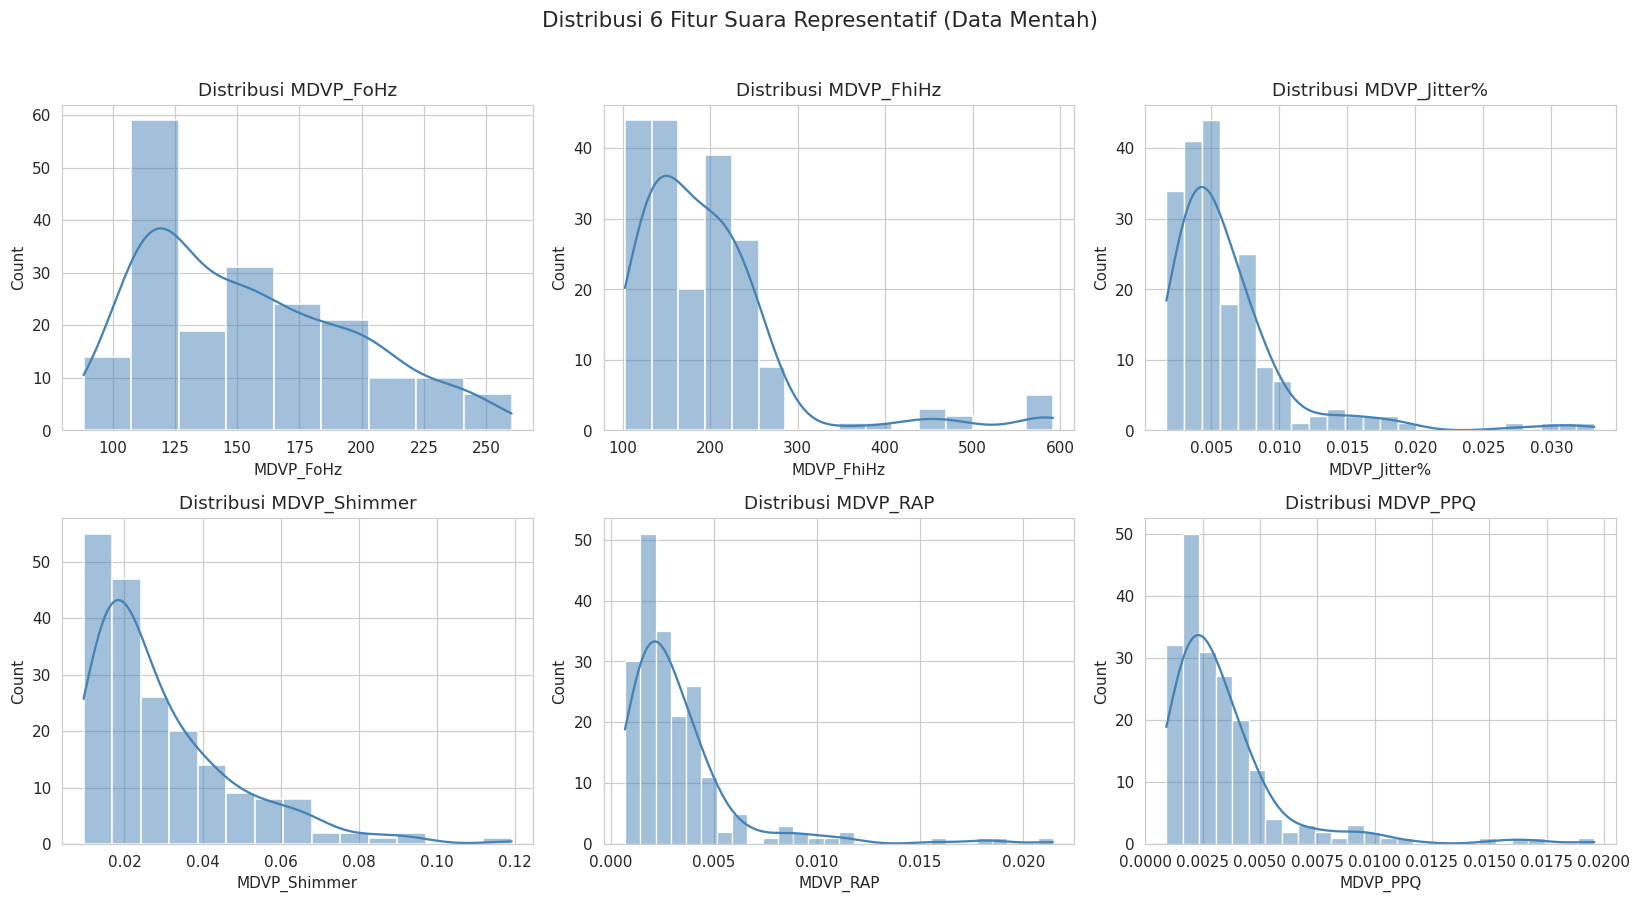

In [10]:
representative_features = ['MDVP_FoHz', 'MDVP_FhiHz', 'MDVP_Jitter%',
                           'MDVP_Shimmer', 'MDVP_RAP', 'MDVP_PPQ']

representative_features = [c for c in representative_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(representative_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribusi {col}")
    axes[i].set_xlabel(col)

plt.suptitle("Distribusi 6 Fitur Suara Representatif (Data Mentah)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3229/2795911264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='status', data=df, palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_3229/2795911264.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Healthy (0)', 'Parkinson\'s (1)'])


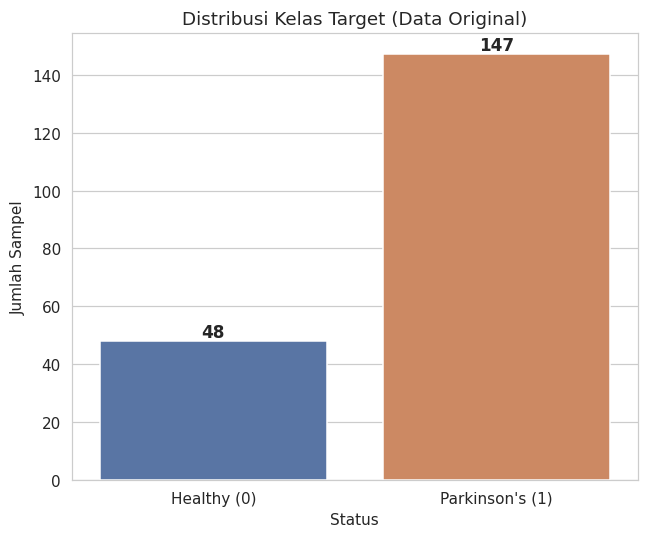

Healthy (0): 48 sampel (24.6%)
Parkinson's (1): 147 sampel (75.4%)


In [11]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='status', data=df, palette=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['Healthy (0)', 'Parkinson\'s (1)'])
ax.set_title("Distribusi Kelas Target (Data Original)")
ax.set_xlabel("Status")
ax.set_ylabel("Jumlah Sampel")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

n_healthy = (df['status'] == 0).sum()
n_pd = (df['status'] == 1).sum()
print(f"Healthy (0): {n_healthy} sampel ({n_healthy/len(df)*100:.1f}%)")
print(f"Parkinson's (1): {n_pd} sampel ({n_pd/len(df)*100:.1f}%)")

Split 60/20/20

In [12]:
X = df[feature_cols].copy()
y = df['status'].copy()

# Tahap 1: train (60%) vs temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)

# Tahap 2: temp dibagi rata -> validation (20%) & test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Ukuran Hasil Split 60/20/20")
print(f"Train      : {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation : {X_val.shape[0]} sampel ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test       : {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.1f}%)")

print("\nDistribusi Kelas Tiap Split (Cek Stratifikasi)")
for name, yset in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    counts = yset.value_counts()
    pct_pd = counts.get(1, 0) / len(yset) * 100
    print(f"{name:<11}: Healthy={counts.get(0,0):>3} | Parkinson's={counts.get(1,0):>3} | %PD={pct_pd:.1f}%")

Ukuran Hasil Split 60/20/20
Train      : 117 sampel (60.0%)
Validation : 39 sampel (20.0%)
Test       : 39 sampel (20.0%)

Distribusi Kelas Tiap Split (Cek Stratifikasi)
Train      : Healthy= 29 | Parkinson's= 88 | %PD=75.2%
Validation : Healthy=  9 | Parkinson's= 30 | %PD=76.9%
Test       : Healthy= 10 | Parkinson's= 29 | %PD=74.4%


Mean fitur training setelah scaling (harus ~0): 0.000000
Std fitur training setelah scaling (harus ~1)  : 1.004301


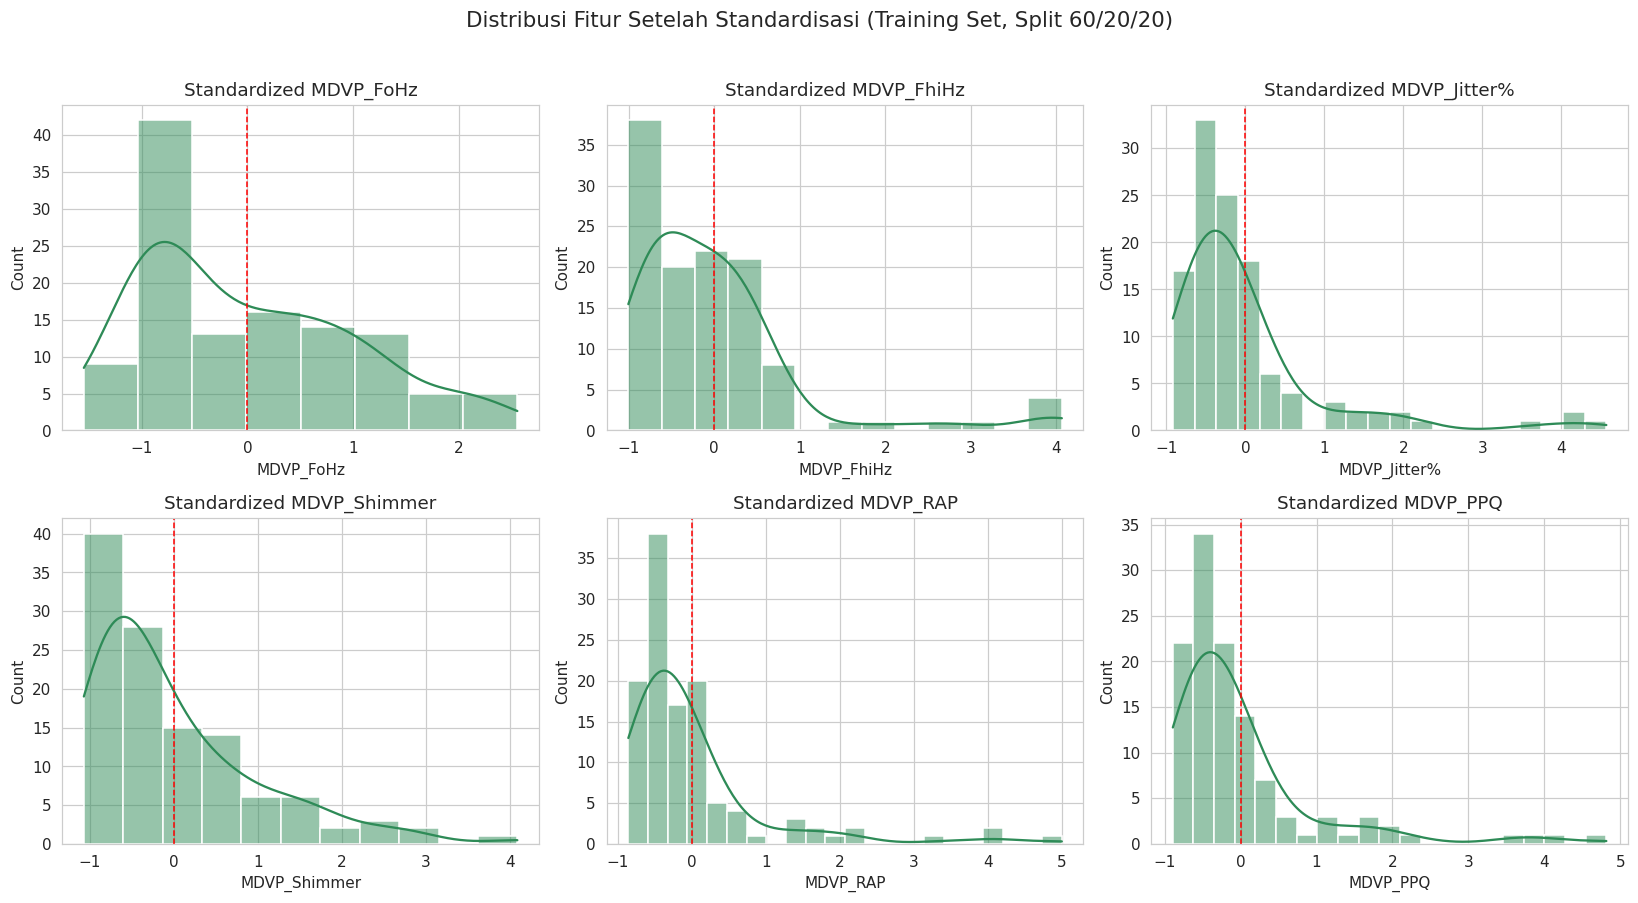

In [13]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), columns=feature_cols, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_cols, index=X_test.index
)

print(f"Mean fitur training setelah scaling (harus ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Std fitur training setelah scaling (harus ~1)  : {X_train_scaled.std().mean():.6f}")

# Visualisasi
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(representative_features):
    sns.histplot(X_train_scaled[col], kde=True, ax=axes[i], color="seagreen")
    axes[i].set_title(f"Standardized {col}")
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1)

plt.suptitle("Distribusi Fitur Setelah Standardisasi (Training Set, Split 60/20/20)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Distribusi Kelas Training SEBELUM SMOTE
status
1    88
0    29
Name: count, dtype: int64

Distribusi Kelas Training SETELAH SMOTE
status
1    88
0    70
Name: count, dtype: int64

Total sampel training setelah SMOTE: 158


/tmp/ipykernel_3229/1089408425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_3229/1089408425.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
/tmp/ipykernel_3229/1089408425.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[1], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_3229/1089408425.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xt

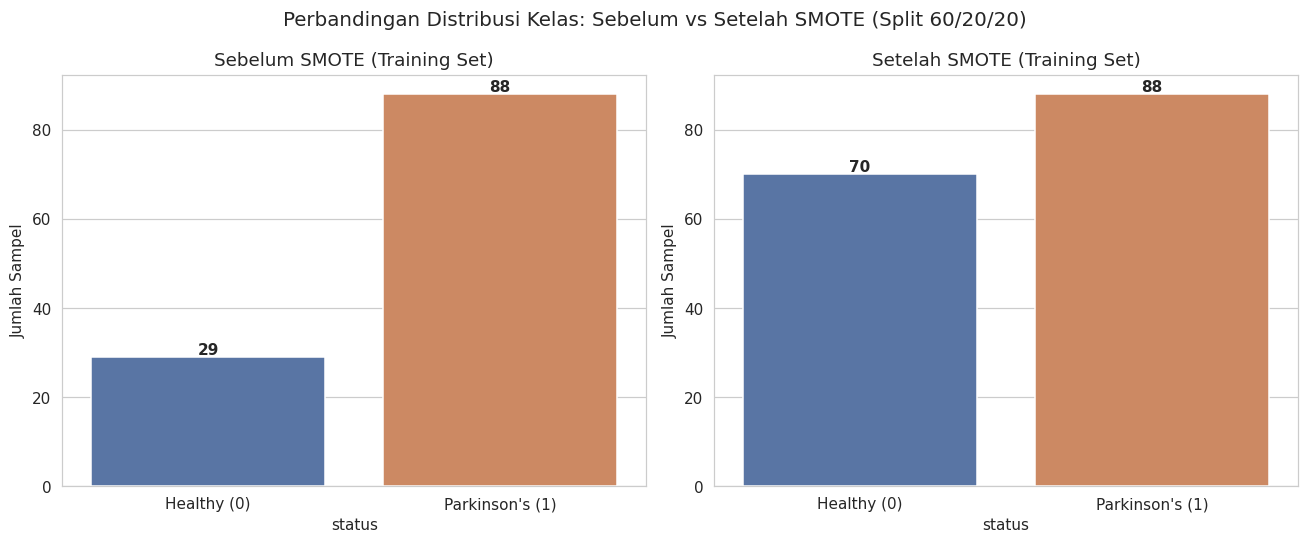

In [14]:
print("Distribusi Kelas Training SEBELUM SMOTE")
print(y_train.value_counts())

smote = SMOTE(sampling_strategy=0.8, k_neighbors=5, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nDistribusi Kelas Training SETELAH SMOTE")
print(y_train_smote.value_counts())
print(f"\nTotal sampel training setelah SMOTE: {len(y_train_smote)}")

# Visualisasi perbandingan sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title("Sebelum SMOTE (Training Set)")
axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
axes[0].set_ylabel("Jumlah Sampel")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontweight='bold')

sns.countplot(x=y_train_smote, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title("Setelah SMOTE (Training Set)")
axes[1].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
axes[1].set_ylabel("Jumlah Sampel")
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontweight='bold')

plt.suptitle("Perbandingan Distribusi Kelas: Sebelum vs Setelah SMOTE (Split 60/20/20)", fontsize=13)
plt.tight_layout()
plt.show()

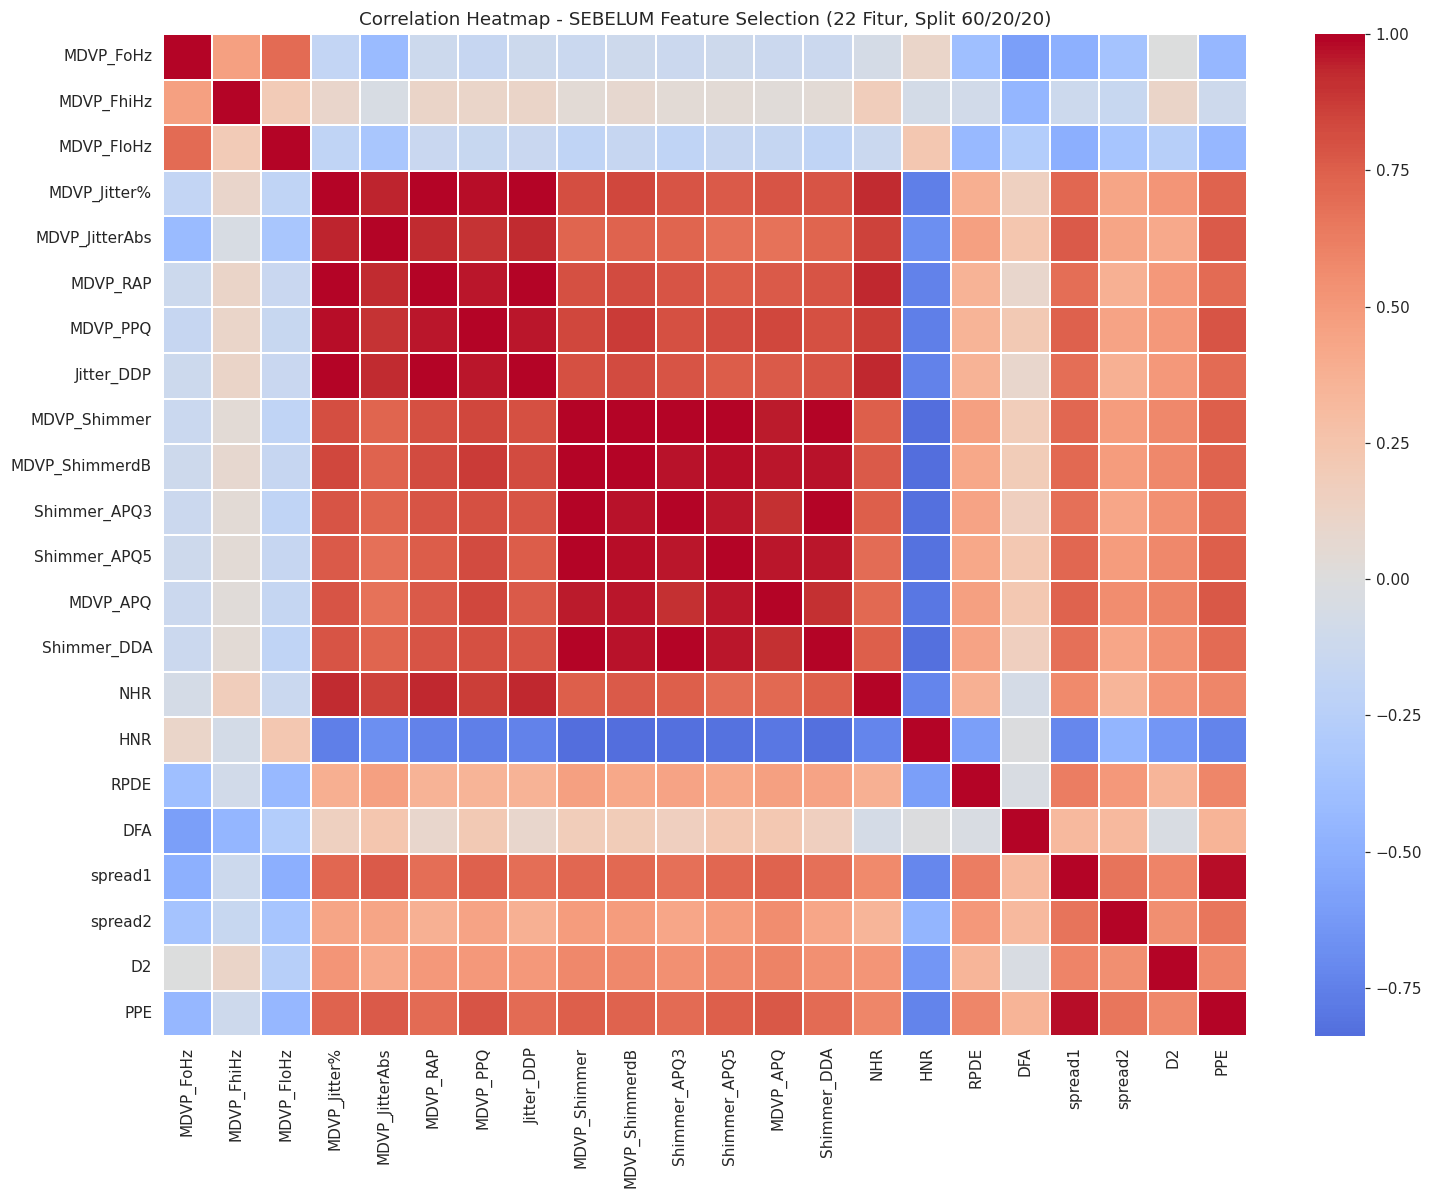

Jumlah fitur yang dibuang karena |rho| > 0.9 : 11
Fitur yang dibuang: ['MDVP_JitterAbs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP', 'MDVP_ShimmerdB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ', 'Shimmer_DDA', 'NHR', 'PPE']

Jumlah fitur yang dipertahankan: 11
Fitur terpilih: ['MDVP_FoHz', 'MDVP_FhiHz', 'MDVP_FloHz', 'MDVP_Jitter%', 'MDVP_Shimmer', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2']


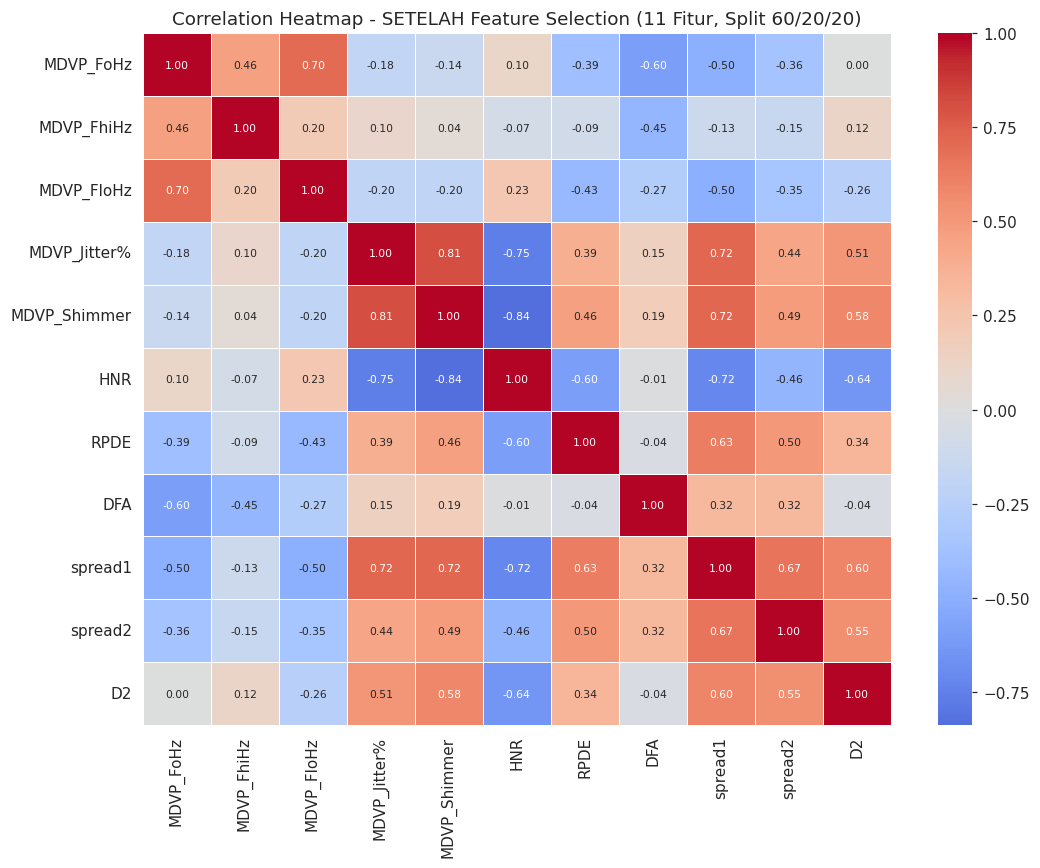

In [15]:
corr_matrix = X_train_smote.corr().abs()

# Visualisasi heatmap SEBELUM feature selection
plt.figure(figsize=(14, 11))
sns.heatmap(X_train_smote.corr(), cmap="coolwarm", center=0, annot=False,
            linewidths=0.3)
plt.title("Correlation Heatmap - SEBELUM Feature Selection (22 Fitur, Split 60/20/20)")
plt.tight_layout()
plt.show()

# Algoritma penghapusan fitur redundan:
# untuk setiap pasangan fitur dengan korelasi > 0.9, buang salah satunya
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]

print(f"Jumlah fitur yang dibuang karena |rho| > 0.9 : {len(to_drop)}")
print(f"Fitur yang dibuang: {to_drop}")

selected_features = [c for c in feature_cols if c not in to_drop]
print(f"\nJumlah fitur yang dipertahankan: {len(selected_features)}")
print(f"Fitur terpilih: {selected_features}")

# Terapkan seleksi fitur ke semua partisi data
X_train_final = X_train_smote[selected_features]
X_val_final = X_val_scaled[selected_features]
X_test_final = X_test_scaled[selected_features]

# Visualisasi heatmap SETELAH feature selection (replikasi Figure 5)
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_final.corr(), cmap="coolwarm", center=0, annot=True,
            fmt=".2f", linewidths=0.5, annot_kws={"size": 7})
plt.title(f"Correlation Heatmap - SETELAH Feature Selection ({len(selected_features)} Fitur, Split 60/20/20)")
plt.tight_layout()
plt.show()

In [16]:
svm_param_grid = {
    'C': [1, 10, 100],
    'gamma': [0.001, 0.01, 0.1],
    'kernel': ['rbf']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_distributions=svm_param_grid,
    n_iter=10,
    scoring='f1',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_search.fit(X_train_final, y_train_smote)

best_svm = svm_search.best_estimator_
print(f"\nBest SVM Params : {svm_search.best_params_}")
print(f"Best CV F1-Score : {svm_search.best_score_:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best SVM Params : {'kernel': 'rbf', 'gamma': 0.1, 'C': 100}
Best CV F1-Score : 0.9272


In [17]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='f1',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_search.fit(X_train_final, y_train_smote)

best_xgb = xgb_search.best_estimator_
print(f"\nBest XGBoost Params : {xgb_search.best_params_}")
print(f"Best CV F1-Score    : {xgb_search.best_score_:.4f}")


Best XGBoost Params : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Best CV F1-Score    : 0.9315


In [18]:
def evaluate_model(model, X, y, model_name, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    print(f"[{dataset_name}] {model_name:<10} -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    return acc, prec, rec, f1

print("Performa pada VALIDATION SET (Split 60/20/20)")
evaluate_model(best_svm, X_val_final, y_val, "SVM", "Validation")
evaluate_model(best_xgb, X_val_final, y_val, "XGBoost", "Validation")

Performa pada VALIDATION SET (Split 60/20/20)
[Validation] SVM        -> Acc: 0.9487 | Prec: 0.9375 | Rec: 1.0000 | F1: 0.9677
[Validation] XGBoost    -> Acc: 0.9487 | Prec: 0.9667 | Rec: 0.9667 | F1: 0.9667


(0.9487179487179487,
 0.9666666666666667,
 0.9666666666666667,
 0.9666666666666667)

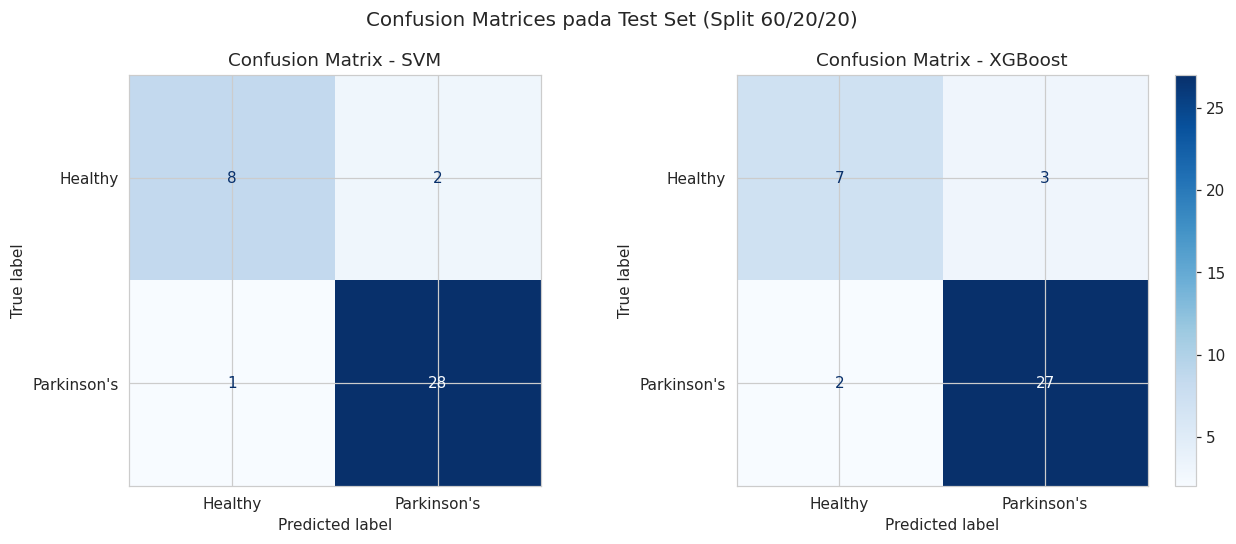


TABEL PERFORMA TEST SET (Split 60/20/20)


,Accuracy,Precision,Recall,F1,Specificity,AUC
SVM,0.9231,0.9333,0.9655,0.9492,0.8,0.9138
XGBoost,0.8718,0.9000,0.9310,0.9153,0.7,0.9000


In [19]:
models = {"SVM": best_svm, "XGBoost": best_xgb}
test_results = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_final)
    y_proba = model.predict_proba(X_test_final)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    test_results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1": f1, "Specificity": specificity, "AUC": auc,
        "y_pred": y_pred, "y_proba": y_proba, "cm": cm
    }

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Parkinson's"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=(i==1))
    axes[i].set_title(f"Confusion Matrix - {name}")

plt.suptitle("Confusion Matrices pada Test Set (Split 60/20/20)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTABEL PERFORMA TEST SET (Split 60/20/20)")
results_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ["y_pred", "y_proba", "cm"]}
    for name, res in test_results.items()
}).T
display(results_df.round(4))

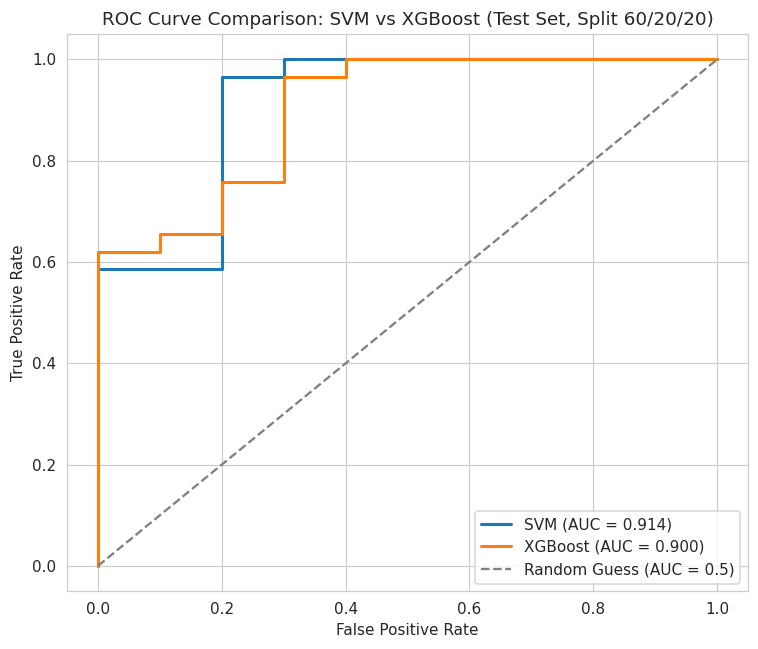

In [20]:
plt.figure(figsize=(7, 6))

for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {res["AUC"]:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: SVM vs XGBoost (Test Set, Split 60/20/20)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

,Model,5-Fold CV Accuracy,Hold-Out Test Accuracy
0,SVM,0.9236,0.9231
1,XGBoost,0.9240,0.8718


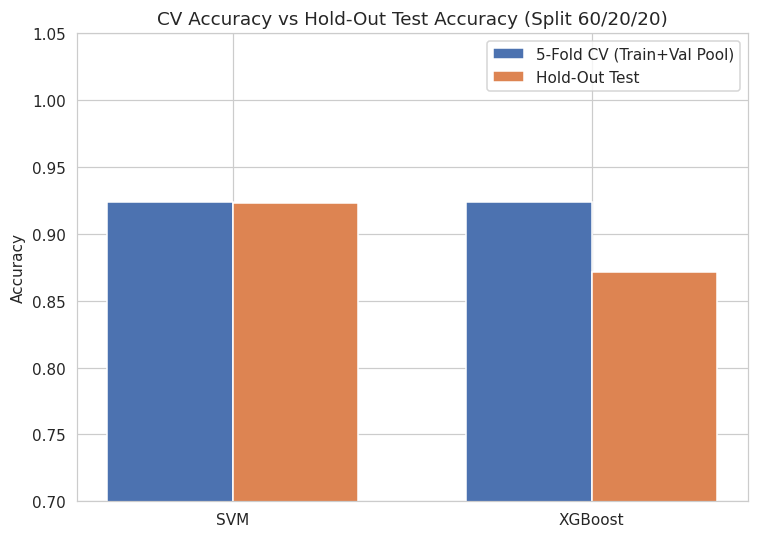


Interpretasi gap:
SVM: gap CV vs Hold-Out = 0.0005 (0.05 poin persentase)
XGBoost: gap CV vs Hold-Out = 0.0522 (5.22 poin persentase)


In [21]:
from sklearn.model_selection import cross_val_score


cv_scores_svm = cross_val_score(best_svm, X_train_final, y_train_smote,
                                  cv=cv_strategy, scoring='accuracy')
cv_scores_xgb = cross_val_score(best_xgb, X_train_final, y_train_smote,
                                  cv=cv_strategy, scoring='accuracy')

comparison_df = pd.DataFrame({
    "Model": ["SVM", "XGBoost"],
    "5-Fold CV Accuracy": [cv_scores_svm.mean(), cv_scores_xgb.mean()],
    "Hold-Out Test Accuracy": [test_results["SVM"]["Accuracy"], test_results["XGBoost"]["Accuracy"]]
})
display(comparison_df.round(4))

# Visualisasi perbandingan
plt.figure(figsize=(7, 5))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df["5-Fold CV Accuracy"], width, label="5-Fold CV (Train+Val Pool)", color="#4C72B0")
plt.bar(x + width/2, comparison_df["Hold-Out Test Accuracy"], width, label="Hold-Out Test", color="#DD8452")

plt.xticks(x, comparison_df["Model"])
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.05)
plt.title("CV Accuracy vs Hold-Out Test Accuracy (Split 60/20/20)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterpretasi gap:")
for i, row in comparison_df.iterrows():
    gap = row["5-Fold CV Accuracy"] - row["Hold-Out Test Accuracy"]
    print(f"{row['Model']}: gap CV vs Hold-Out = {gap:.4f} ({gap*100:.2f} poin persentase)")

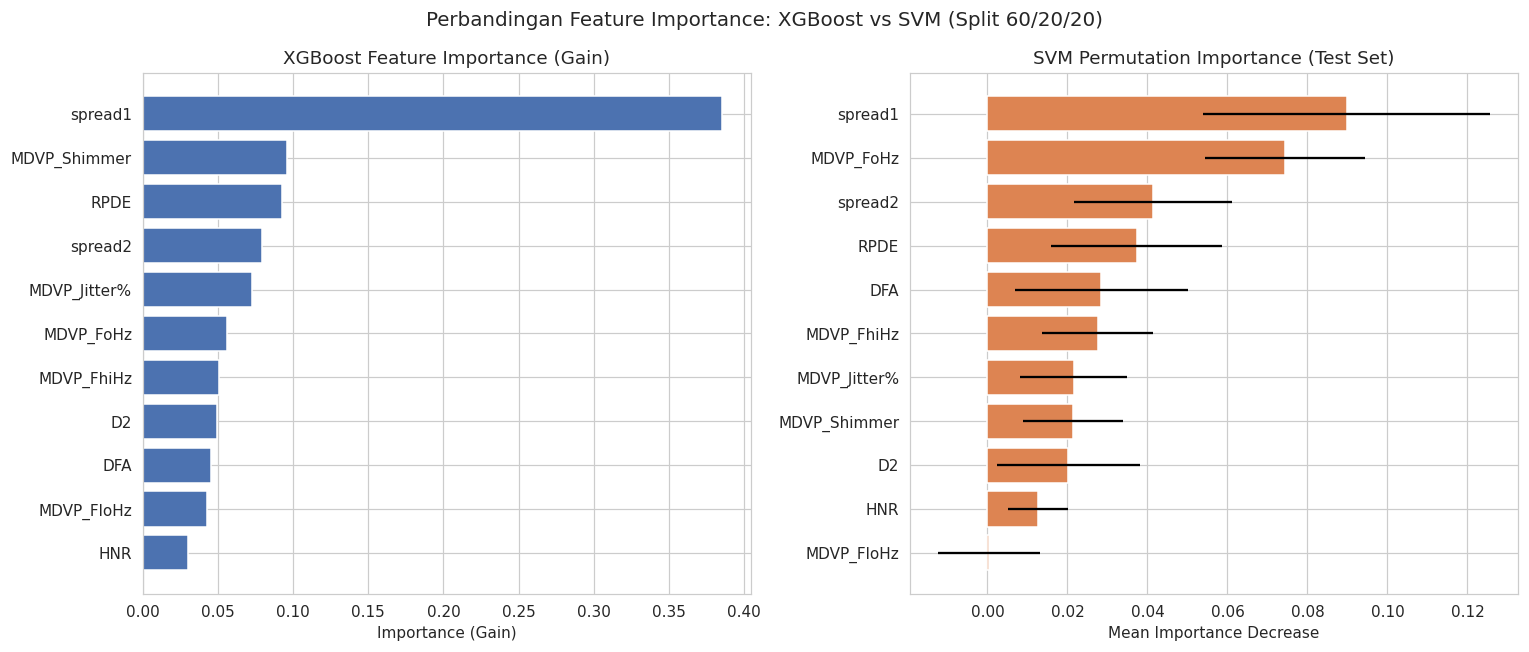

Top-3 fitur terpenting (XGBoost - Gain)   : ['spread1', 'MDVP_Shimmer', 'RPDE']
Top-3 fitur terpenting (SVM - Permutation): ['spread1', 'MDVP_FoHz', 'spread2']


In [22]:
# XGBoost: Gain-based importance
xgb_importance = pd.Series(best_xgb.feature_importances_, index=selected_features)
xgb_importance = xgb_importance.sort_values(ascending=True)

# SVM: Permutation importance (model-agnostic, dihitung pada test set)
perm_result = permutation_importance(best_svm, X_test_final, y_test,
                                       n_repeats=30, random_state=RANDOM_STATE, scoring='f1')
svm_importance = pd.Series(perm_result.importances_mean, index=selected_features)
svm_importance_std = pd.Series(perm_result.importances_std, index=selected_features)
svm_importance_sorted = svm_importance.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(xgb_importance.index, xgb_importance.values, color="#4C72B0")
axes[0].set_title("XGBoost Feature Importance (Gain)")
axes[0].set_xlabel("Importance (Gain)")

axes[1].barh(svm_importance_sorted.index, svm_importance_sorted.values,
             xerr=svm_importance_std[svm_importance_sorted.index], color="#DD8452")
axes[1].set_title("SVM Permutation Importance (Test Set)")
axes[1].set_xlabel("Mean Importance Decrease")

plt.suptitle("Perbandingan Feature Importance: XGBoost vs SVM (Split 60/20/20)", fontsize=13)
plt.tight_layout()
plt.show()

print("Top-3 fitur terpenting (XGBoost - Gain)   :", xgb_importance.sort_values(ascending=False).head(3).index.tolist())
print("Top-3 fitur terpenting (SVM - Permutation):", svm_importance.sort_values(ascending=False).head(3).index.tolist())

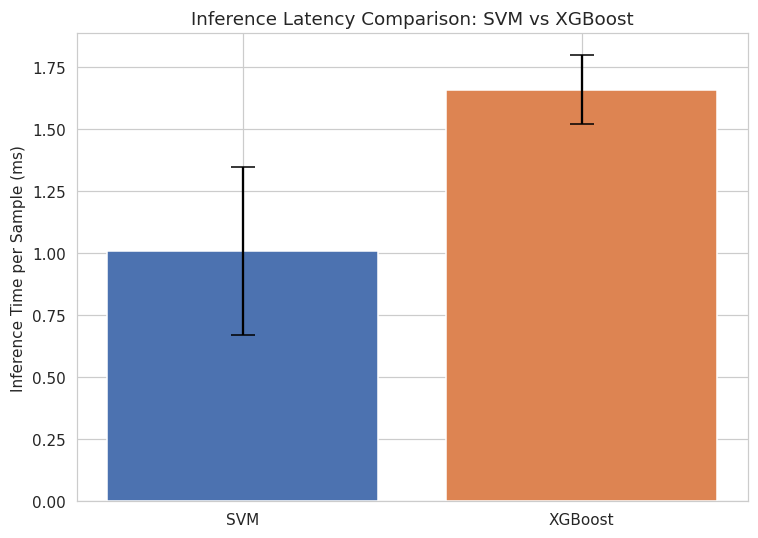

SVM: mean = 1.007 ms | std = 0.337 ms
XGBoost: mean = 1.657 ms | std = 0.138 ms


In [23]:
n_repeats_latency = 100
latency_results = {}

for name, model in models.items():
    times = []
    for _ in range(n_repeats_latency):
        idx = np.random.randint(0, len(X_test_final))
        sample = X_test_final.iloc[[idx]]
        start = time.perf_counter()
        _ = model.predict(sample)
        end = time.perf_counter()
        times.append((end - start) * 1000)  # convert ke milliseconds
    latency_results[name] = times

plt.figure(figsize=(7, 5))
plt.bar(latency_results.keys(),
        [np.mean(v) for v in latency_results.values()],
        yerr=[np.std(v) for v in latency_results.values()],
        capsize=8, color=["#4C72B0", "#DD8452"])
plt.ylabel("Inference Time per Sample (ms)")
plt.title("Inference Latency Comparison: SVM vs XGBoost")
plt.tight_layout()
plt.show()

for name, times in latency_results.items():
    print(f"{name}: mean = {np.mean(times):.3f} ms | std = {np.std(times):.3f} ms")

In [24]:
summary_602020 = {
    "split_name": "60/20/20",
    "n_train": len(y_train), "n_val": len(y_val), "n_test": len(y_test),
    "n_features_selected": len(selected_features),
    "selected_features": selected_features,
    "svm_best_params": svm_search.best_params_,
    "xgb_best_params": xgb_search.best_params_,
    "svm_cv_acc": cv_scores_svm.mean(),
    "xgb_cv_acc": cv_scores_xgb.mean(),
    "svm_test": {k: v for k, v in test_results["SVM"].items() if k not in ["y_pred", "y_proba", "cm"]},
    "xgb_test": {k: v for k, v in test_results["XGBoost"].items() if k not in ["y_pred", "y_proba", "cm"]},
    "svm_latency_ms": np.mean(latency_results["SVM"]),
    "xgb_latency_ms": np.mean(latency_results["XGBoost"]),
}

print("RINGKASAN PIPELINE SPLIT 60/20/20\n")
print(f"Train: {summary_602020['n_train']} | Val: {summary_602020['n_val']} | Test: {summary_602020['n_test']}")
print(f"Fitur terpilih: {summary_602020['n_features_selected']} dari 22 fitur awal\n")
print("Performa Test Set:")
display(pd.DataFrame({"SVM": summary_602020["svm_test"], "XGBoost": summary_602020["xgb_test"]}).round(4))
print(f"\nGap CV vs Test - SVM     : {summary_602020['svm_cv_acc'] - summary_602020['svm_test']['Accuracy']:.4f}")
print(f"Gap CV vs Test - XGBoost : {summary_602020['xgb_cv_acc'] - summary_602020['xgb_test']['Accuracy']:.4f}")

RINGKASAN PIPELINE SPLIT 60/20/20

Train: 117 | Val: 39 | Test: 39
Fitur terpilih: 11 dari 22 fitur awal

Performa Test Set:


,SVM,XGBoost
Accuracy,0.9231,0.8718
Precision,0.9333,0.9000
Recall,0.9655,0.9310
F1,0.9492,0.9153
Specificity,0.8000,0.7000
AUC,0.9138,0.9000



Gap CV vs Test - SVM     : 0.0005
Gap CV vs Test - XGBoost : 0.0522


Split 80/10/10

In [25]:
# Tahap 1: train (80%) vs temp (20%)
X_train_8010, X_temp_8010, y_train_8010, y_temp_8010 = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Tahap 2: temp (20%) dibagi rata -> validation (10%) & test (10%)
X_val_8010, X_test_8010, y_val_8010, y_test_8010 = train_test_split(
    X_temp_8010, y_temp_8010, test_size=0.50, stratify=y_temp_8010, random_state=RANDOM_STATE
)

print("Ukuran Hasil Split 80/10/10")
print(f"Train      : {X_train_8010.shape[0]} sampel ({X_train_8010.shape[0]/len(df)*100:.1f}%)")
print(f"Validation : {X_val_8010.shape[0]} sampel ({X_val_8010.shape[0]/len(df)*100:.1f}%)")
print(f"Test       : {X_test_8010.shape[0]} sampel ({X_test_8010.shape[0]/len(df)*100:.1f}%)")

print("\nDistribusi Kelas Tiap Split (Cek Stratifikasi)")
for name, yset in [("Train", y_train_8010), ("Validation", y_val_8010), ("Test", y_test_8010)]:
    counts = yset.value_counts()
    pct_pd = counts.get(1, 0) / len(yset) * 100
    print(f"{name:<11}: Healthy={counts.get(0,0):>3} | Parkinson's={counts.get(1,0):>3} | %PD={pct_pd:.1f}%")

Ukuran Hasil Split 80/10/10
Train      : 156 sampel (80.0%)
Validation : 19 sampel (9.7%)
Test       : 20 sampel (10.3%)

Distribusi Kelas Tiap Split (Cek Stratifikasi)
Train      : Healthy= 38 | Parkinson's=118 | %PD=75.6%
Validation : Healthy=  5 | Parkinson's= 14 | %PD=73.7%
Test       : Healthy=  5 | Parkinson's= 15 | %PD=75.0%


Standardisasi selesai (Split 80/10/10).
Mean fitur training setelah scaling (harus ~0): -0.000000
Std fitur training setelah scaling (harus ~1)  : 1.003221


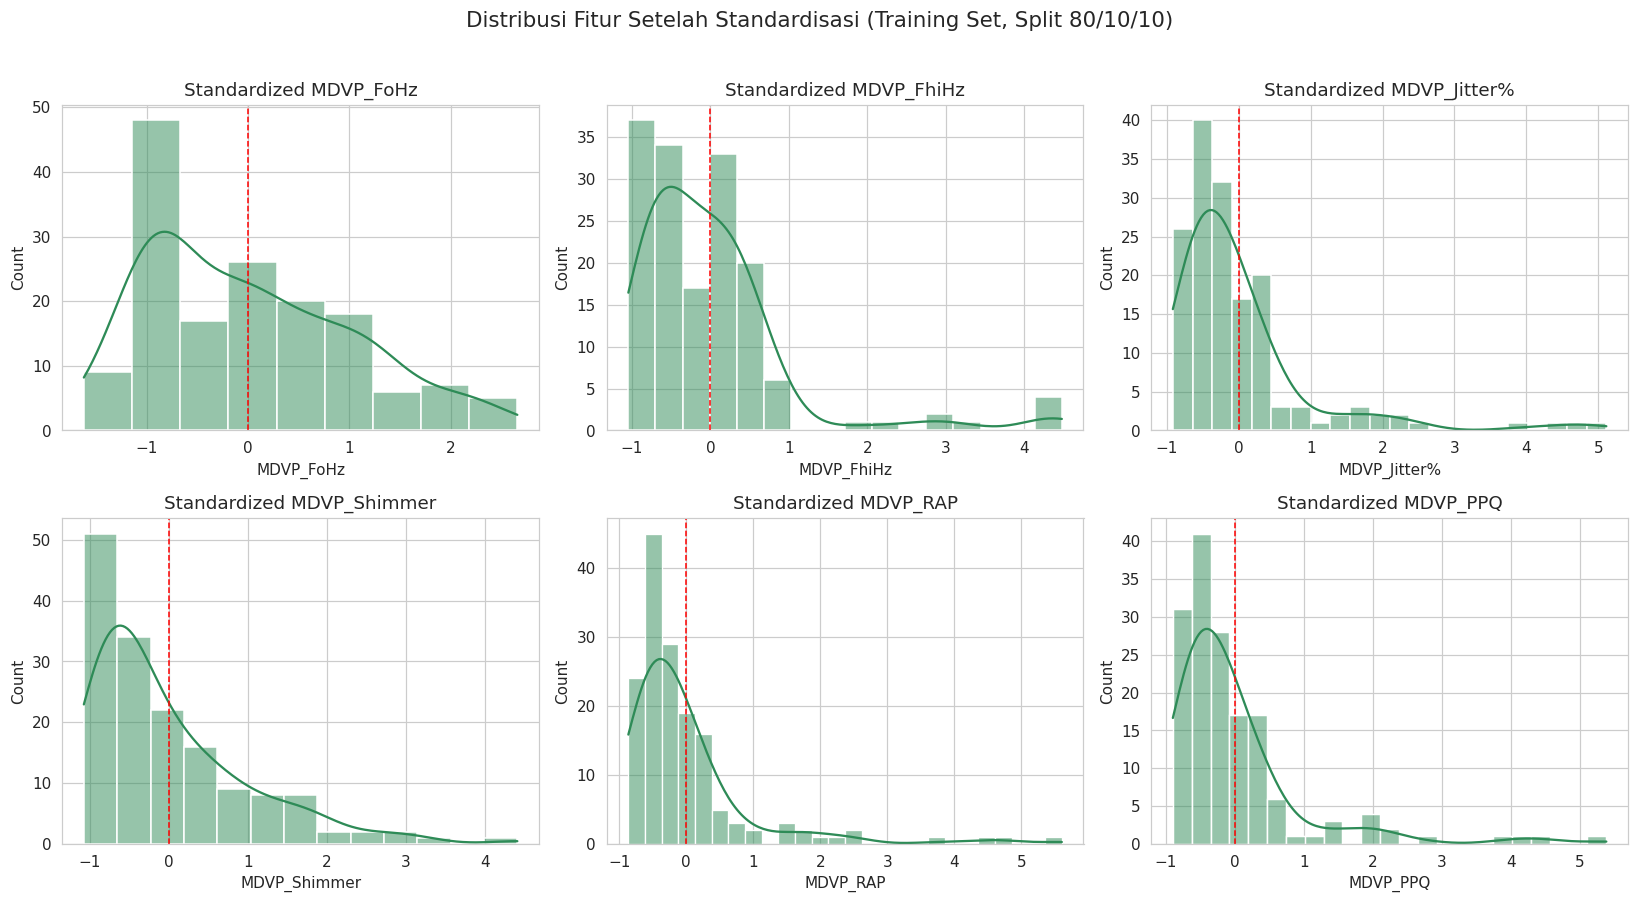

In [26]:
scaler_8010 = StandardScaler()

X_train_scaled_8010 = pd.DataFrame(
    scaler_8010.fit_transform(X_train_8010), columns=feature_cols, index=X_train_8010.index
)
X_val_scaled_8010 = pd.DataFrame(
    scaler_8010.transform(X_val_8010), columns=feature_cols, index=X_val_8010.index
)
X_test_scaled_8010 = pd.DataFrame(
    scaler_8010.transform(X_test_8010), columns=feature_cols, index=X_test_8010.index
)

print("Standardisasi selesai (Split 80/10/10).")
print(f"Mean fitur training setelah scaling (harus ~0): {X_train_scaled_8010.mean().mean():.6f}")
print(f"Std fitur training setelah scaling (harus ~1)  : {X_train_scaled_8010.std().mean():.6f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(representative_features):
    sns.histplot(X_train_scaled_8010[col], kde=True, ax=axes[i], color="seagreen")
    axes[i].set_title(f"Standardized {col}")
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1)
plt.suptitle("Distribusi Fitur Setelah Standardisasi (Training Set, Split 80/10/10)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

istribusi Kelas Training SEBELUM SMOTE (80/10/10)
status
1    118
0     38
Name: count, dtype: int64

Distribusi Kelas Training SETELAH SMOTE (80/10/10)
status
1    118
0     94
Name: count, dtype: int64
Total sampel training setelah SMOTE: 212


/tmp/ipykernel_3229/3252597860.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_8010, ax=axes[0], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_3229/3252597860.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
/tmp/ipykernel_3229/3252597860.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote_8010, ax=axes[1], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_3229/3252597860.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes

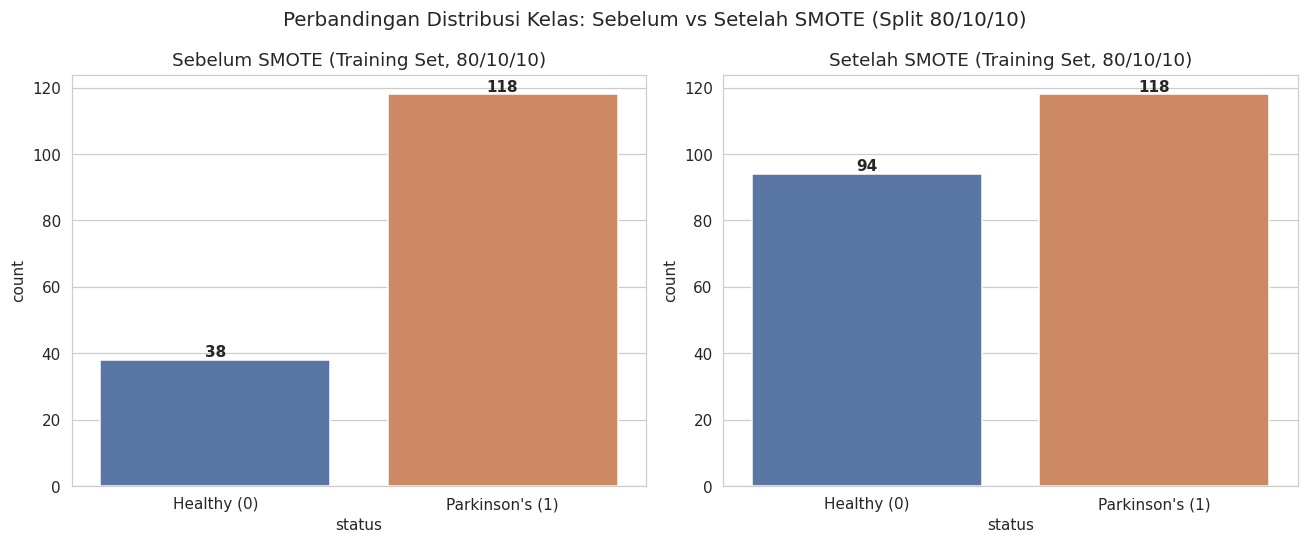

In [27]:
print("istribusi Kelas Training SEBELUM SMOTE (80/10/10)")
print(y_train_8010.value_counts())

smote_8010 = SMOTE(sampling_strategy=0.8, k_neighbors=5, random_state=RANDOM_STATE)
X_train_smote_8010, y_train_smote_8010 = smote_8010.fit_resample(X_train_scaled_8010, y_train_8010)

print("\nDistribusi Kelas Training SETELAH SMOTE (80/10/10)")
print(y_train_smote_8010.value_counts())
print(f"Total sampel training setelah SMOTE: {len(y_train_smote_8010)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train_8010, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title("Sebelum SMOTE (Training Set, 80/10/10)")
axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontweight='bold')

sns.countplot(x=y_train_smote_8010, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title("Setelah SMOTE (Training Set, 80/10/10)")
axes[1].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.suptitle("Perbandingan Distribusi Kelas: Sebelum vs Setelah SMOTE (Split 80/10/10)", fontsize=13)
plt.tight_layout()
plt.show()

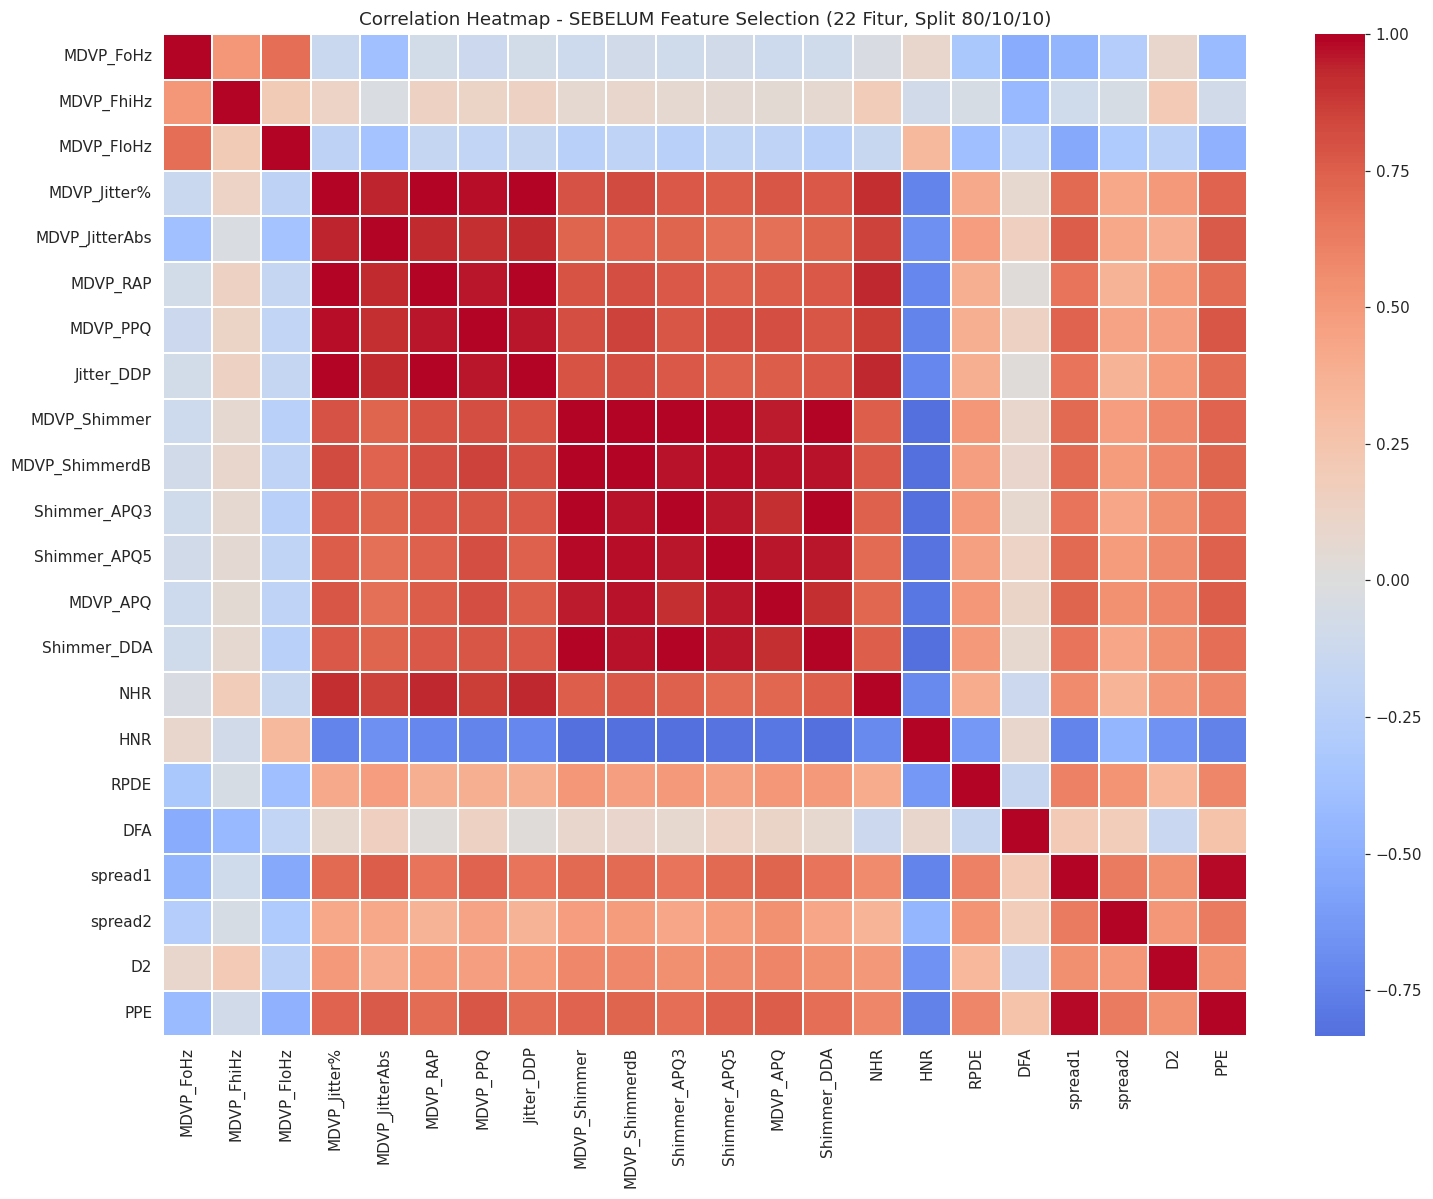

Jumlah fitur yang dibuang karena |rho| > 0.9 : 11
Fitur yang dibuang: ['MDVP_JitterAbs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP', 'MDVP_ShimmerdB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ', 'Shimmer_DDA', 'NHR', 'PPE']

Jumlah fitur yang dipertahankan: 11
Fitur terpilih: ['MDVP_FoHz', 'MDVP_FhiHz', 'MDVP_FloHz', 'MDVP_Jitter%', 'MDVP_Shimmer', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2']


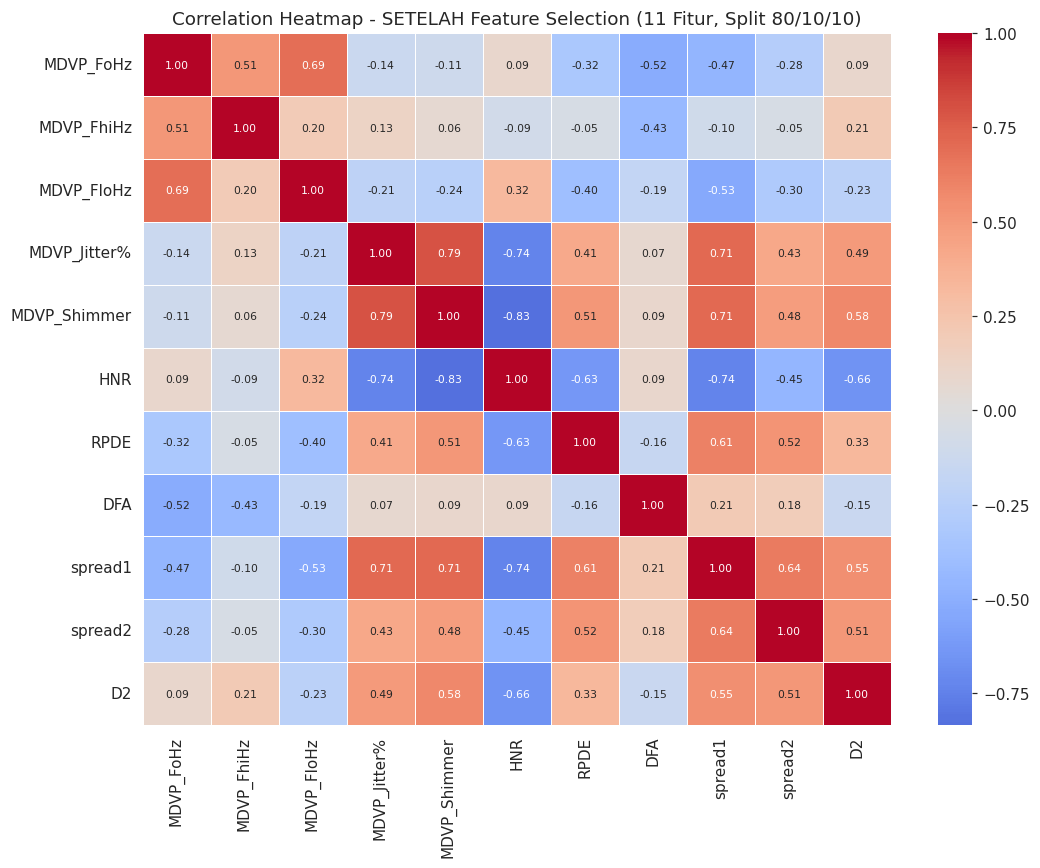

In [28]:
corr_matrix_8010 = X_train_smote_8010.corr().abs()

plt.figure(figsize=(14, 11))
sns.heatmap(X_train_smote_8010.corr(), cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap - SEBELUM Feature Selection (22 Fitur, Split 80/10/10)")
plt.tight_layout()
plt.show()

upper_tri_8010 = corr_matrix_8010.where(np.triu(np.ones(corr_matrix_8010.shape), k=1).astype(bool))
to_drop_8010 = [col for col in upper_tri_8010.columns if any(upper_tri_8010[col] > 0.9)]

print(f"Jumlah fitur yang dibuang karena |rho| > 0.9 : {len(to_drop_8010)}")
print(f"Fitur yang dibuang: {to_drop_8010}")

selected_features_8010 = [c for c in feature_cols if c not in to_drop_8010]
print(f"\nJumlah fitur yang dipertahankan: {len(selected_features_8010)}")
print(f"Fitur terpilih: {selected_features_8010}")

X_train_final_8010 = X_train_smote_8010[selected_features_8010]
X_val_final_8010 = X_val_scaled_8010[selected_features_8010]
X_test_final_8010 = X_test_scaled_8010[selected_features_8010]

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_final_8010.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size": 7})
plt.title(f"Correlation Heatmap - SETELAH Feature Selection ({len(selected_features_8010)} Fitur, Split 80/10/10)")
plt.tight_layout()
plt.show()

In [29]:
cv_strategy_8010 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# SVM
svm_search_8010 = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_distributions=svm_param_grid,
    n_iter=10, scoring='f1', cv=cv_strategy_8010,
    random_state=RANDOM_STATE, n_jobs=-1
)
print("Menjalankan RandomizedSearchCV untuk SVM (80/10/10)...")
svm_search_8010.fit(X_train_final_8010, y_train_smote_8010)
best_svm_8010 = svm_search_8010.best_estimator_
print(f"Best SVM Params : {svm_search_8010.best_params_}")
print(f"Best CV F1-Score : {svm_search_8010.best_score_:.4f}")

# XGBoost
xgb_search_8010 = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=10, scoring='f1', cv=cv_strategy_8010,
    random_state=RANDOM_STATE, n_jobs=-1
)
print("\nMenjalankan RandomizedSearchCV untuk XGBoost (80/10/10)...")
xgb_search_8010.fit(X_train_final_8010, y_train_smote_8010)
best_xgb_8010 = xgb_search_8010.best_estimator_
print(f"Best XGBoost Params : {xgb_search_8010.best_params_}")
print(f"Best CV F1-Score    : {xgb_search_8010.best_score_:.4f}")

Menjalankan RandomizedSearchCV untuk SVM (80/10/10)...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best SVM Params : {'kernel': 'rbf', 'gamma': 0.1, 'C': 10}
Best CV F1-Score : 0.9698

Menjalankan RandomizedSearchCV untuk XGBoost (80/10/10)...
Best XGBoost Params : {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best CV F1-Score    : 0.9484


In [30]:
print("Performa pada VALIDATION SET (Split 80/10/10)")
evaluate_model(best_svm_8010, X_val_final_8010, y_val_8010, "SVM", "Validation")
evaluate_model(best_xgb_8010, X_val_final_8010, y_val_8010, "XGBoost", "Validation")
print(f"\nCatatan: validation set hanya berisi {len(y_val_8010)} sampel pada skema ini,")
print("sehingga setiap kesalahan prediksi tunggal berdampak besar pada persentase metrik.")

Performa pada VALIDATION SET (Split 80/10/10)
[Validation] SVM        -> Acc: 0.7895 | Prec: 0.9167 | Rec: 0.7857 | F1: 0.8462
[Validation] XGBoost    -> Acc: 0.7895 | Prec: 0.8571 | Rec: 0.8571 | F1: 0.8571

Catatan: validation set hanya berisi 19 sampel pada skema ini,
sehingga setiap kesalahan prediksi tunggal berdampak besar pada persentase metrik.


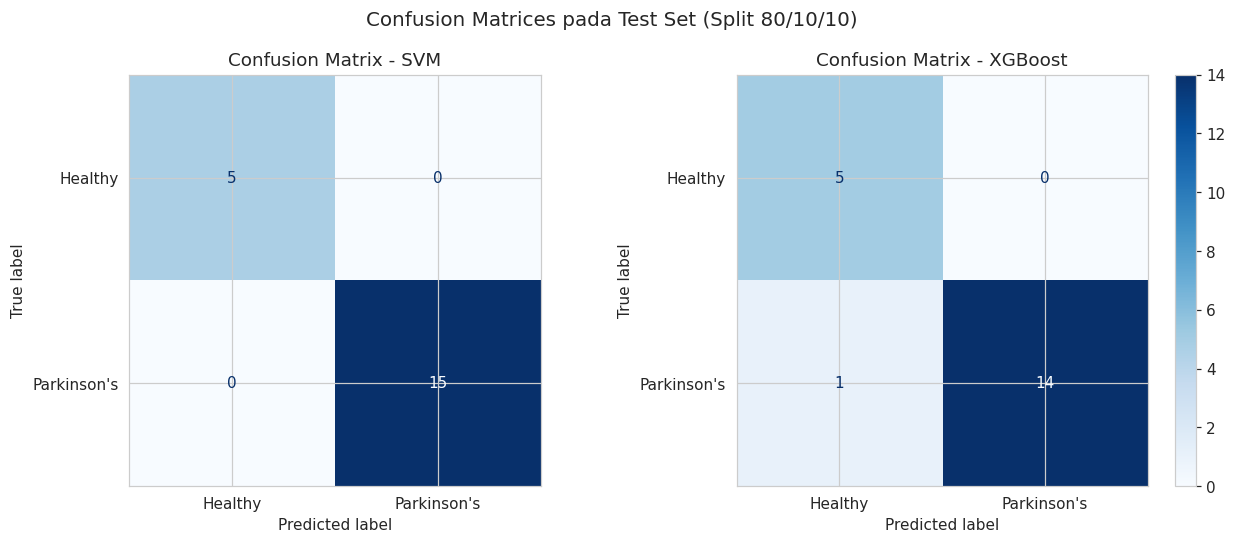


=== TABEL PERFORMA TEST SET (Split 80/10/10) ===


,Accuracy,Precision,Recall,F1,Specificity,AUC
SVM,1.00,1.0,1.0000,1.0000,1.0,1.0
XGBoost,0.95,1.0,0.9333,0.9655,1.0,1.0


In [31]:
models_8010 = {"SVM": best_svm_8010, "XGBoost": best_xgb_8010}
test_results_8010 = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models_8010.items()):
    y_pred = model.predict(X_test_final_8010)
    y_proba = model.predict_proba(X_test_final_8010)[:, 1]

    acc = accuracy_score(y_test_8010, y_pred)
    prec = precision_score(y_test_8010, y_pred)
    rec = recall_score(y_test_8010, y_pred)
    f1 = f1_score(y_test_8010, y_pred)
    auc = roc_auc_score(y_test_8010, y_proba)

    cm = confusion_matrix(y_test_8010, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    test_results_8010[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1": f1, "Specificity": specificity, "AUC": auc,
        "y_pred": y_pred, "y_proba": y_proba, "cm": cm
    }

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Parkinson's"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=(i==1))
    axes[i].set_title(f"Confusion Matrix - {name}")

plt.suptitle("Confusion Matrices pada Test Set (Split 80/10/10)", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== TABEL PERFORMA TEST SET (Split 80/10/10) ===")
results_df_8010 = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ["y_pred", "y_proba", "cm"]}
    for name, res in test_results_8010.items()
}).T
display(results_df_8010.round(4))

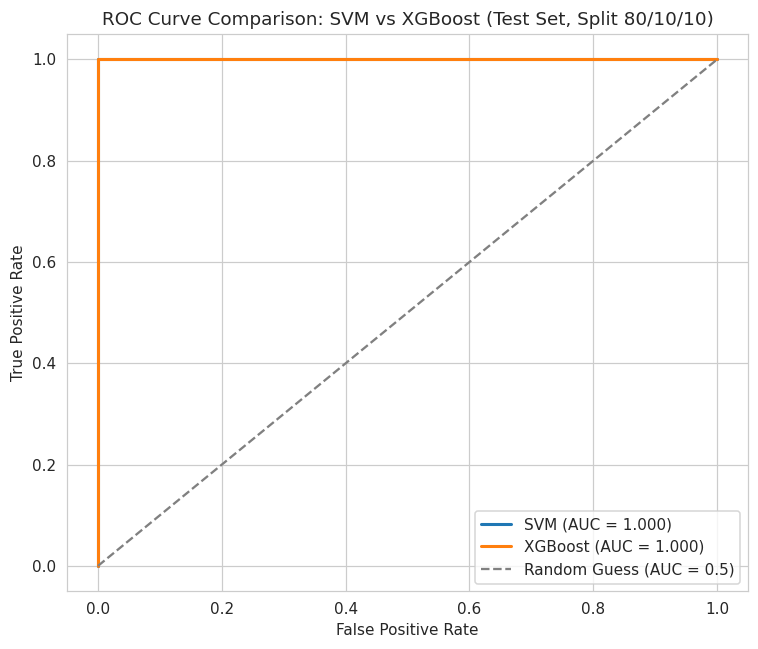

In [32]:
plt.figure(figsize=(7, 6))
for name, res in test_results_8010.items():
    fpr, tpr, _ = roc_curve(y_test_8010, res["y_proba"])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {res["AUC"]:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: SVM vs XGBoost (Test Set, Split 80/10/10)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

,Model,5-Fold CV Accuracy,Hold-Out Test Accuracy
0,SVM,0.9671,1.00
1,XGBoost,0.9435,0.95


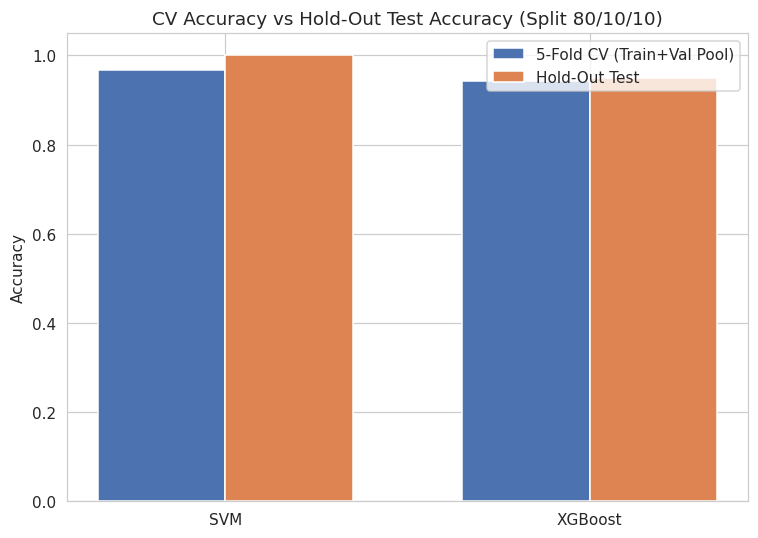

In [33]:
cv_scores_svm_8010 = cross_val_score(best_svm_8010, X_train_final_8010, y_train_smote_8010,
                                       cv=cv_strategy_8010, scoring='accuracy')
cv_scores_xgb_8010 = cross_val_score(best_xgb_8010, X_train_final_8010, y_train_smote_8010,
                                       cv=cv_strategy_8010, scoring='accuracy')

comparison_df_8010 = pd.DataFrame({
    "Model": ["SVM", "XGBoost"],
    "5-Fold CV Accuracy": [cv_scores_svm_8010.mean(), cv_scores_xgb_8010.mean()],
    "Hold-Out Test Accuracy": [test_results_8010["SVM"]["Accuracy"], test_results_8010["XGBoost"]["Accuracy"]]
})
display(comparison_df_8010.round(4))

plt.figure(figsize=(7, 5))
x = np.arange(len(comparison_df_8010))
width = 0.35
plt.bar(x - width/2, comparison_df_8010["5-Fold CV Accuracy"], width, label="5-Fold CV (Train+Val Pool)", color="#4C72B0")
plt.bar(x + width/2, comparison_df_8010["Hold-Out Test Accuracy"], width, label="Hold-Out Test", color="#DD8452")
plt.xticks(x, comparison_df_8010["Model"])
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("CV Accuracy vs Hold-Out Test Accuracy (Split 80/10/10)")
plt.legend()
plt.tight_layout()
plt.show()

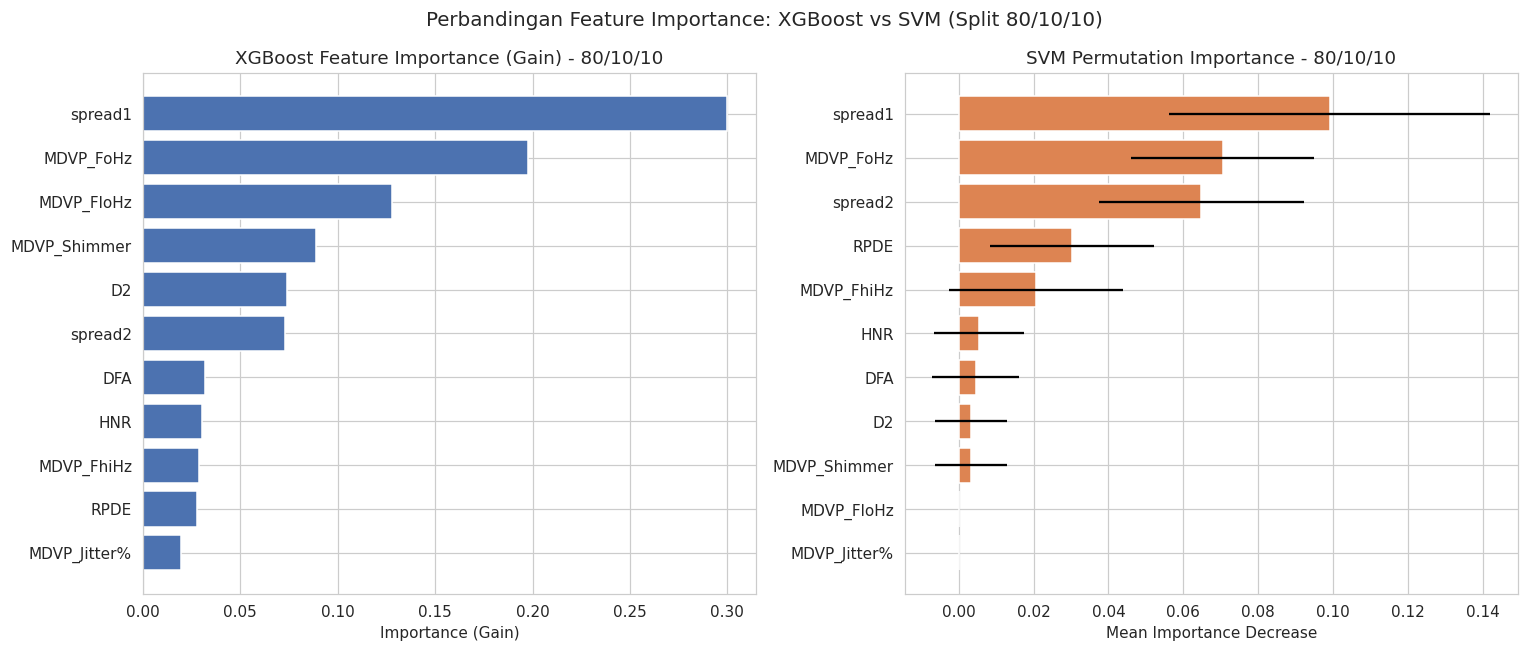

In [34]:
xgb_importance_8010 = pd.Series(best_xgb_8010.feature_importances_, index=selected_features_8010).sort_values(ascending=True)

perm_result_8010 = permutation_importance(best_svm_8010, X_test_final_8010, y_test_8010,
                                            n_repeats=30, random_state=RANDOM_STATE, scoring='f1')
svm_importance_8010 = pd.Series(perm_result_8010.importances_mean, index=selected_features_8010)
svm_importance_std_8010 = pd.Series(perm_result_8010.importances_std, index=selected_features_8010)
svm_importance_sorted_8010 = svm_importance_8010.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(xgb_importance_8010.index, xgb_importance_8010.values, color="#4C72B0")
axes[0].set_title("XGBoost Feature Importance (Gain) - 80/10/10")
axes[0].set_xlabel("Importance (Gain)")

axes[1].barh(svm_importance_sorted_8010.index, svm_importance_sorted_8010.values,
             xerr=svm_importance_std_8010[svm_importance_sorted_8010.index], color="#DD8452")
axes[1].set_title("SVM Permutation Importance - 80/10/10")
axes[1].set_xlabel("Mean Importance Decrease")

plt.suptitle("Perbandingan Feature Importance: XGBoost vs SVM (Split 80/10/10)", fontsize=13)
plt.tight_layout()
plt.show()

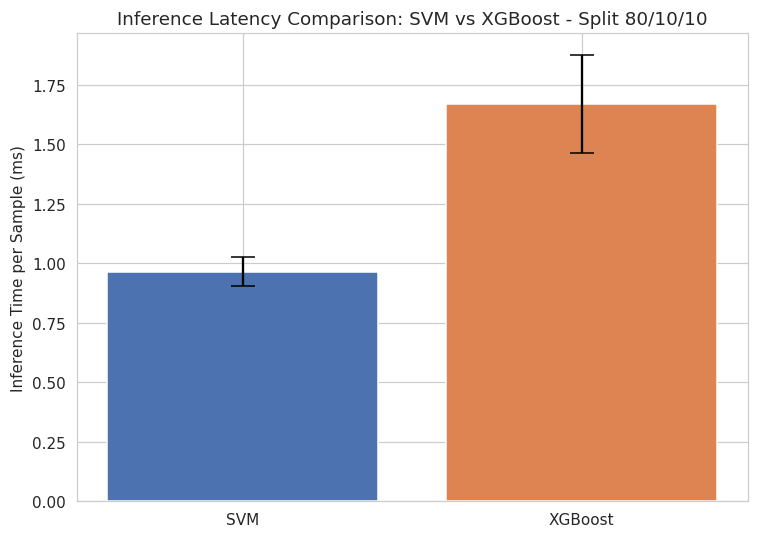

SVM: mean = 0.965 ms | std = 0.060 ms
XGBoost: mean = 1.668 ms | std = 0.206 ms


In [35]:
latency_results_8010 = {}
for name, model in models_8010.items():
    times = []
    for _ in range(n_repeats_latency):
        idx = np.random.randint(0, len(X_test_final_8010))
        sample = X_test_final_8010.iloc[[idx]]
        start = time.perf_counter()
        _ = model.predict(sample)
        end = time.perf_counter()
        times.append((end - start) * 1000)
    latency_results_8010[name] = times

plt.figure(figsize=(7, 5))
plt.bar(latency_results_8010.keys(),
        [np.mean(v) for v in latency_results_8010.values()],
        yerr=[np.std(v) for v in latency_results_8010.values()],
        capsize=8, color=["#4C72B0", "#DD8452"])
plt.ylabel("Inference Time per Sample (ms)")
plt.title("Inference Latency Comparison: SVM vs XGBoost - Split 80/10/10")
plt.tight_layout()
plt.show()

for name, times in latency_results_8010.items():
    print(f"{name}: mean = {np.mean(times):.3f} ms | std = {np.std(times):.3f} ms")

In [36]:
summary_801010 = {
    "split_name": "80/10/10",
    "n_train": len(y_train_8010), "n_val": len(y_val_8010), "n_test": len(y_test_8010),
    "n_features_selected": len(selected_features_8010),
    "selected_features": selected_features_8010,
    "svm_best_params": svm_search_8010.best_params_,
    "xgb_best_params": xgb_search_8010.best_params_,
    "svm_cv_acc": cv_scores_svm_8010.mean(),
    "xgb_cv_acc": cv_scores_xgb_8010.mean(),
    "svm_test": {k: v for k, v in test_results_8010["SVM"].items() if k not in ["y_pred", "y_proba", "cm"]},
    "xgb_test": {k: v for k, v in test_results_8010["XGBoost"].items() if k not in ["y_pred", "y_proba", "cm"]},
    "svm_latency_ms": np.mean(latency_results_8010["SVM"]),
    "xgb_latency_ms": np.mean(latency_results_8010["XGBoost"]),
}

print("RINGKASAN PIPELINE SPLIT 80/10/10\n")
print(f"Train: {summary_801010['n_train']} | Val: {summary_801010['n_val']} | Test: {summary_801010['n_test']}")
print(f"Fitur terpilih: {summary_801010['n_features_selected']} dari 22 fitur awal\n")
display(pd.DataFrame({"SVM": summary_801010["svm_test"], "XGBoost": summary_801010["xgb_test"]}).round(4))
print(f"\nGap CV vs Test - SVM     : {summary_801010['svm_cv_acc'] - summary_801010['svm_test']['Accuracy']:.4f}")
print(f"Gap CV vs Test - XGBoost : {summary_801010['xgb_cv_acc'] - summary_801010['xgb_test']['Accuracy']:.4f}")

RINGKASAN PIPELINE SPLIT 80/10/10

Train: 156 | Val: 19 | Test: 20
Fitur terpilih: 11 dari 22 fitur awal



,SVM,XGBoost
Accuracy,1.0,0.9500
Precision,1.0,1.0000
Recall,1.0,0.9333
F1,1.0,0.9655
Specificity,1.0,1.0000
AUC,1.0,1.0000



Gap CV vs Test - SVM     : -0.0329
Gap CV vs Test - XGBoost : -0.0065


Split 70/20/10

In [37]:
# Tahap 1: train (70%) vs temp (30%)
X_train_7020, X_temp_7020, y_train_7020, y_temp_7020 = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# Tahap 2: temp (30%) dibagi -> validation (20% dari total = 2/3 dari temp)
#          & test (10% dari total = 1/3 dari temp)
X_val_7020, X_test_7020, y_val_7020, y_test_7020 = train_test_split(
    X_temp_7020, y_temp_7020, test_size=(1/3), stratify=y_temp_7020, random_state=RANDOM_STATE
)

print("=== Ukuran Hasil Split 70/20/10 ===")
print(f"Train      : {X_train_7020.shape[0]} sampel ({X_train_7020.shape[0]/len(df)*100:.1f}%)")
print(f"Validation : {X_val_7020.shape[0]} sampel ({X_val_7020.shape[0]/len(df)*100:.1f}%)")
print(f"Test       : {X_test_7020.shape[0]} sampel ({X_test_7020.shape[0]/len(df)*100:.1f}%)")

print("\n=== Distribusi Kelas Tiap Split (Cek Stratifikasi) ===")
for name, yset in [("Train", y_train_7020), ("Validation", y_val_7020), ("Test", y_test_7020)]:
    counts = yset.value_counts()
    pct_pd = counts.get(1, 0) / len(yset) * 100
    print(f"{name:<11}: Healthy={counts.get(0,0):>3} | Parkinson's={counts.get(1,0):>3} | %PD={pct_pd:.1f}%")

=== Ukuran Hasil Split 70/20/10 ===
Train      : 136 sampel (69.7%)
Validation : 39 sampel (20.0%)
Test       : 20 sampel (10.3%)

=== Distribusi Kelas Tiap Split (Cek Stratifikasi) ===
Train      : Healthy= 33 | Parkinson's=103 | %PD=75.7%
Validation : Healthy= 10 | Parkinson's= 29 | %PD=74.4%
Test       : Healthy=  5 | Parkinson's= 15 | %PD=75.0%


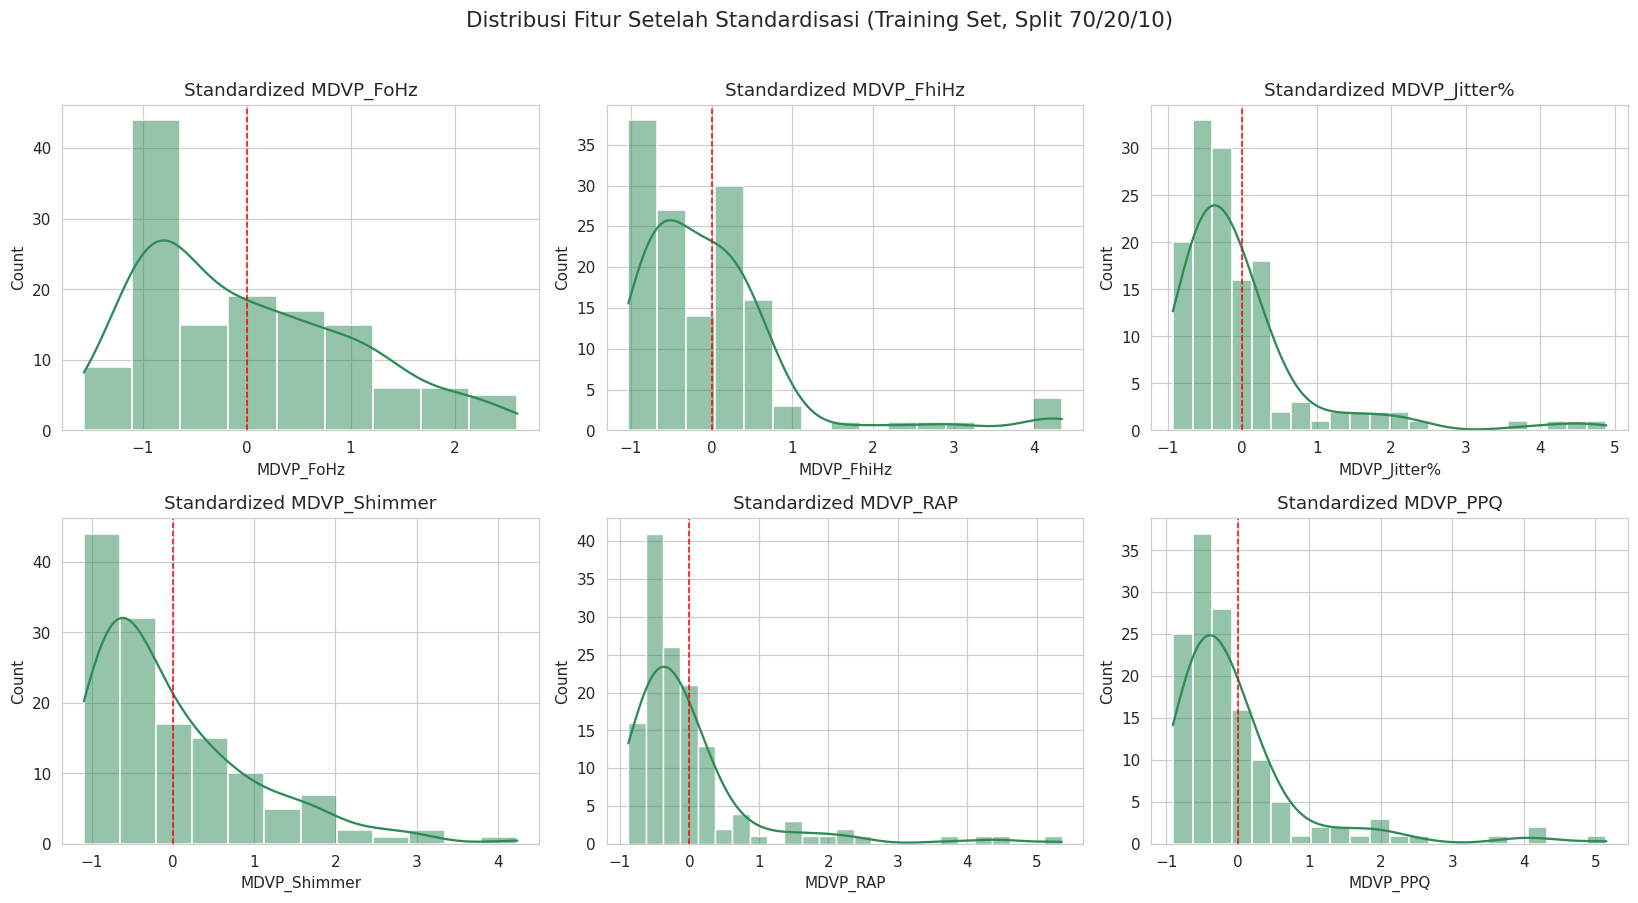

In [38]:
scaler_7020 = StandardScaler()
X_train_scaled_7020 = pd.DataFrame(scaler_7020.fit_transform(X_train_7020), columns=feature_cols, index=X_train_7020.index)
X_val_scaled_7020 = pd.DataFrame(scaler_7020.transform(X_val_7020), columns=feature_cols, index=X_val_7020.index)
X_test_scaled_7020 = pd.DataFrame(scaler_7020.transform(X_test_7020), columns=feature_cols, index=X_test_7020.index)


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(representative_features):
    sns.histplot(X_train_scaled_7020[col], kde=True, ax=axes[i], color="seagreen")
    axes[i].set_title(f"Standardized {col}")
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1)
plt.suptitle("Distribusi Fitur Setelah Standardisasi (Training Set, Split 70/20/10)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Distribusi Kelas Training SEBELUM SMOTE (70/20/10)
status
1    103
0     33
Name: count, dtype: int64

Distribusi Kelas Training SETELAH SMOTE (70/20/10)
status
1    103
0     82
Name: count, dtype: int64


/tmp/ipykernel_3229/1972872062.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_7020, ax=axes[0], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_3229/1972872062.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
/tmp/ipykernel_3229/1972872062.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote_7020, ax=axes[1], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_3229/1972872062.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes

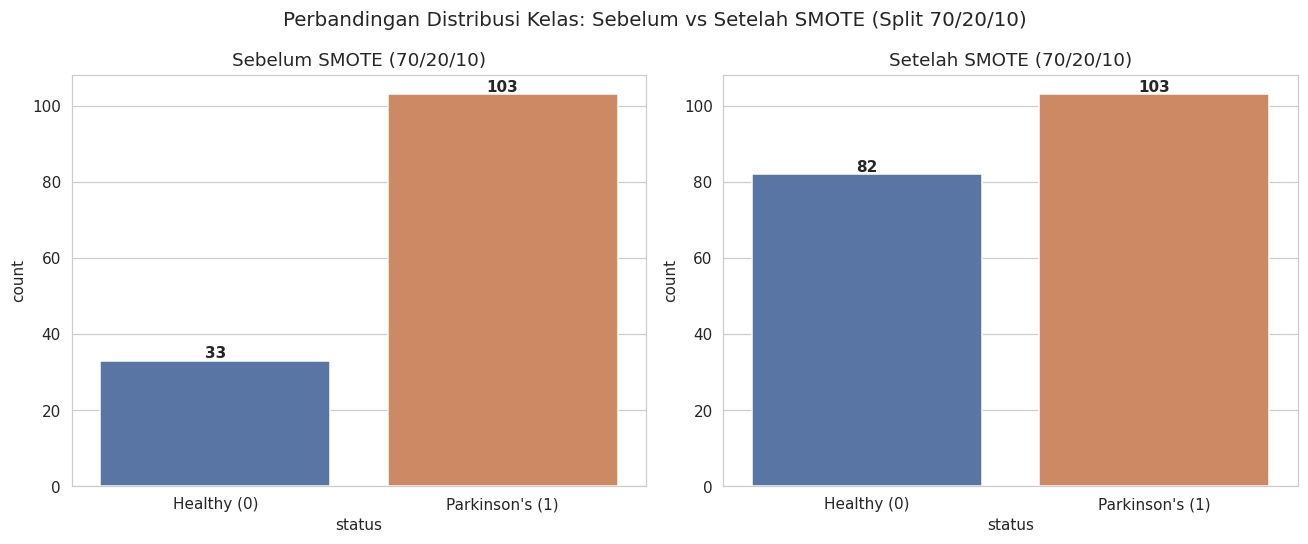

In [39]:
print("Distribusi Kelas Training SEBELUM SMOTE (70/20/10)")
print(y_train_7020.value_counts())

smote_7020 = SMOTE(sampling_strategy=0.8, k_neighbors=5, random_state=RANDOM_STATE)
X_train_smote_7020, y_train_smote_7020 = smote_7020.fit_resample(X_train_scaled_7020, y_train_7020)

print("\nDistribusi Kelas Training SETELAH SMOTE (70/20/10)")
print(y_train_smote_7020.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train_7020, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title("Sebelum SMOTE (70/20/10)")
axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontweight='bold')

sns.countplot(x=y_train_smote_7020, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title("Setelah SMOTE (70/20/10)")
axes[1].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.suptitle("Perbandingan Distribusi Kelas: Sebelum vs Setelah SMOTE (Split 70/20/10)", fontsize=13)
plt.tight_layout()
plt.show()

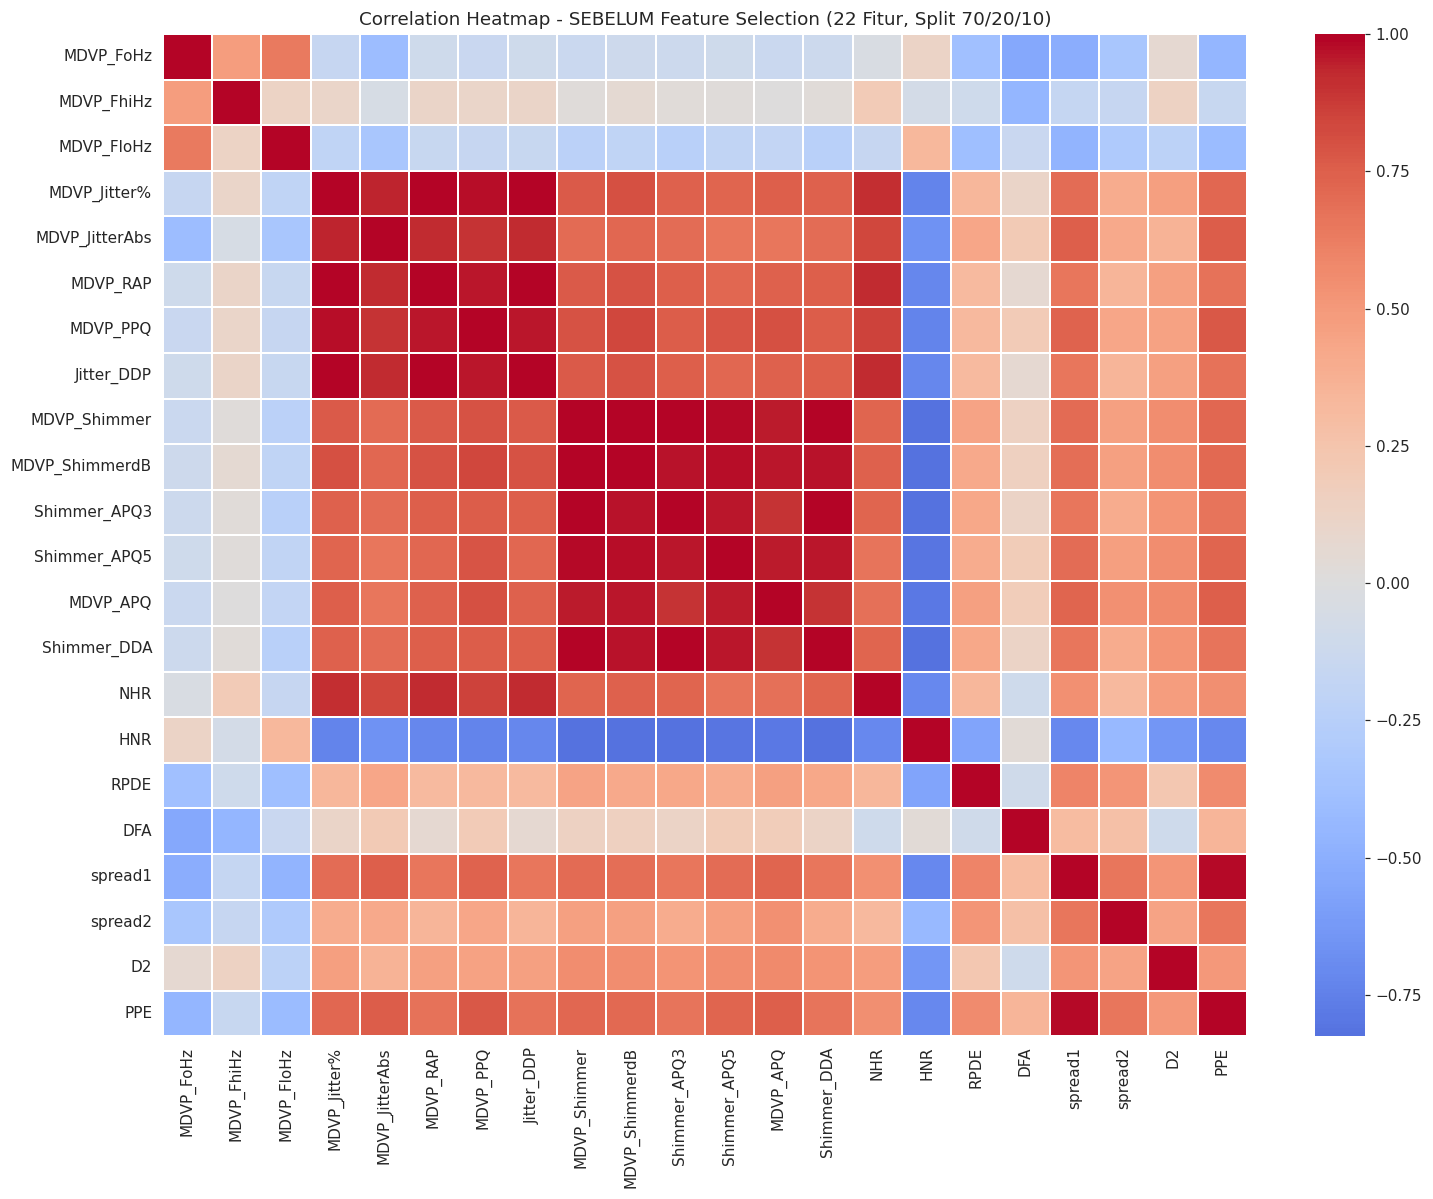

Jumlah fitur yang dibuang karena |rho| > 0.9 : 11
Fitur yang dibuang: ['MDVP_JitterAbs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP', 'MDVP_ShimmerdB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ', 'Shimmer_DDA', 'NHR', 'PPE']

Jumlah fitur yang dipertahankan: 11


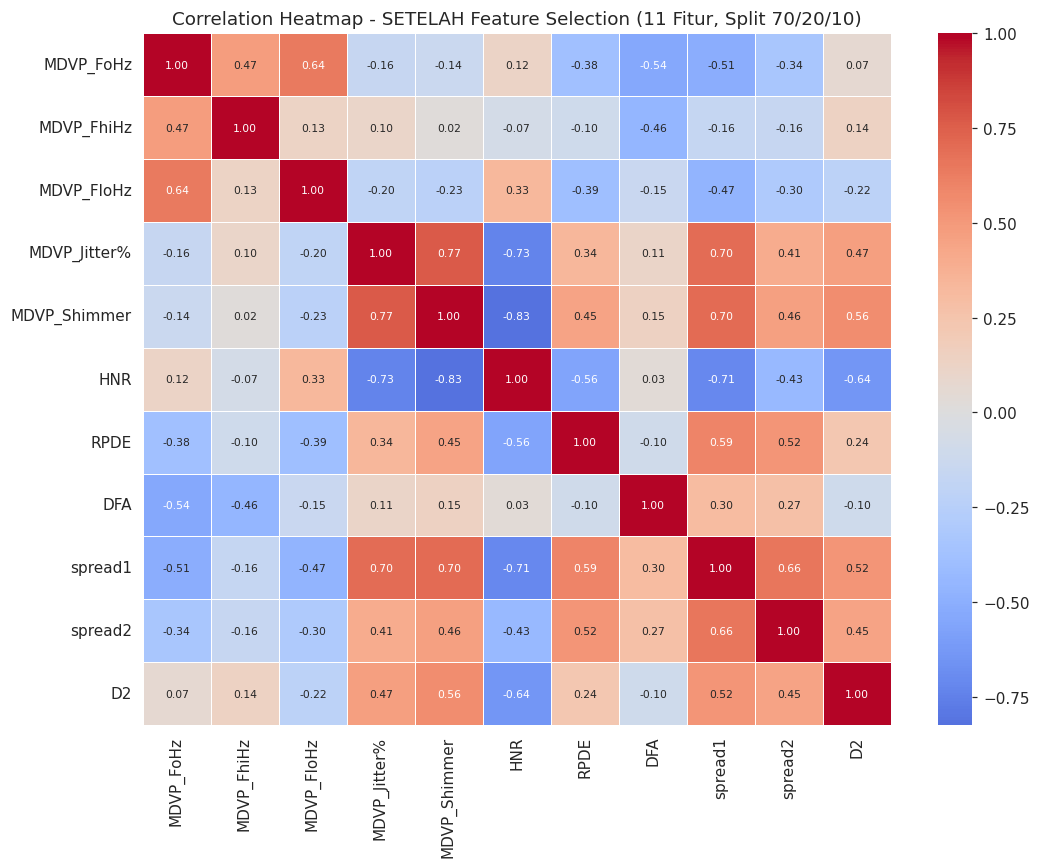

In [40]:
corr_matrix_7020 = X_train_smote_7020.corr().abs()

plt.figure(figsize=(14, 11))
sns.heatmap(X_train_smote_7020.corr(), cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap - SEBELUM Feature Selection (22 Fitur, Split 70/20/10)")
plt.tight_layout()
plt.show()

upper_tri_7020 = corr_matrix_7020.where(np.triu(np.ones(corr_matrix_7020.shape), k=1).astype(bool))
to_drop_7020 = [col for col in upper_tri_7020.columns if any(upper_tri_7020[col] > 0.9)]

print(f"Jumlah fitur yang dibuang karena |rho| > 0.9 : {len(to_drop_7020)}")
print(f"Fitur yang dibuang: {to_drop_7020}")

selected_features_7020 = [c for c in feature_cols if c not in to_drop_7020]
print(f"\nJumlah fitur yang dipertahankan: {len(selected_features_7020)}")

X_train_final_7020 = X_train_smote_7020[selected_features_7020]
X_val_final_7020 = X_val_scaled_7020[selected_features_7020]
X_test_final_7020 = X_test_scaled_7020[selected_features_7020]

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_final_7020.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size": 7})
plt.title(f"Correlation Heatmap - SETELAH Feature Selection ({len(selected_features_7020)} Fitur, Split 70/20/10)")
plt.tight_layout()
plt.show()

In [41]:
cv_strategy_7020 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_search_7020 = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_distributions=svm_param_grid,
    n_iter=10, scoring='f1', cv=cv_strategy_7020,
    random_state=RANDOM_STATE, n_jobs=-1
)

svm_search_7020.fit(X_train_final_7020, y_train_smote_7020)
best_svm_7020 = svm_search_7020.best_estimator_
print(f"Best SVM Params : {svm_search_7020.best_params_}")
print(f"Best CV F1-Score : {svm_search_7020.best_score_:.4f}")

xgb_search_7020 = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=10, scoring='f1', cv=cv_strategy_7020,
    random_state=RANDOM_STATE, n_jobs=-1
)

xgb_search_7020.fit(X_train_final_7020, y_train_smote_7020)
best_xgb_7020 = xgb_search_7020.best_estimator_
print(f"Best XGBoost Params : {xgb_search_7020.best_params_}")
print(f"Best CV F1-Score    : {xgb_search_7020.best_score_:.4f}")

print("\nPerforma pada VALIDATION SET (Split 70/20/10)")
evaluate_model(best_svm_7020, X_val_final_7020, y_val_7020, "SVM", "Validation")
evaluate_model(best_xgb_7020, X_val_final_7020, y_val_7020, "XGBoost", "Validation")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best SVM Params : {'kernel': 'rbf', 'gamma': 0.1, 'C': 10}
Best CV F1-Score : 0.9595
Best XGBoost Params : {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best CV F1-Score    : 0.9400

Performa pada VALIDATION SET (Split 70/20/10)
[Validation] SVM        -> Acc: 0.8974 | Prec: 0.9032 | Rec: 0.9655 | F1: 0.9333
[Validation] XGBoost    -> Acc: 0.9231 | Prec: 0.9062 | Rec: 1.0000 | F1: 0.9508


(0.9230769230769231, 0.90625, 1.0, 0.9508196721311475)

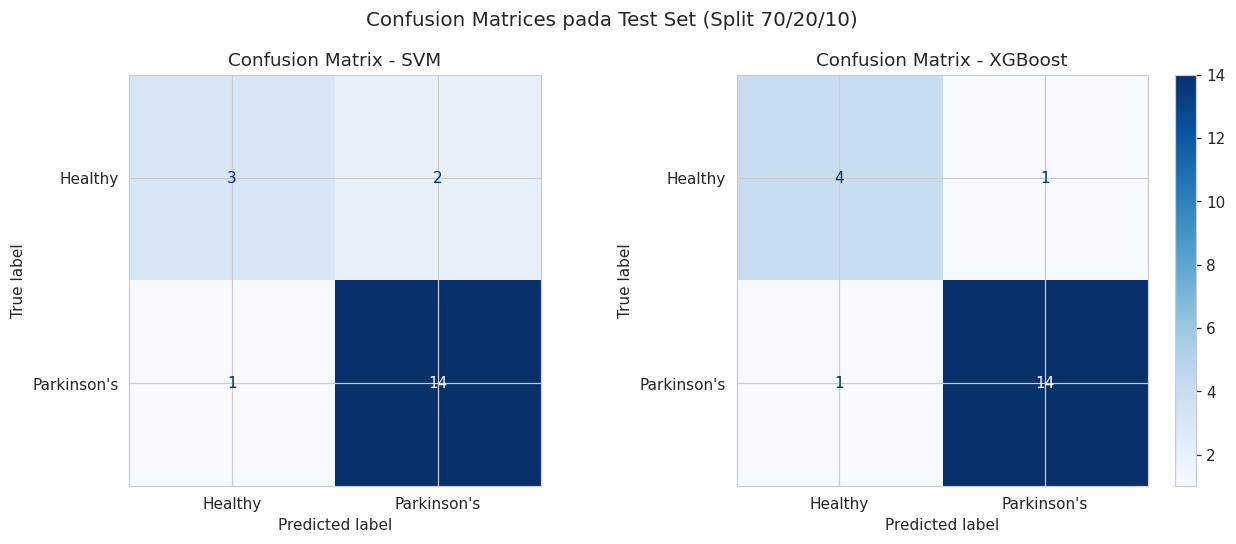


TABEL PERFORMA TEST SET (Split 70/20/10)


,Accuracy,Precision,Recall,F1,Specificity,AUC
SVM,0.85,0.8750,0.9333,0.9032,0.6,0.9733
XGBoost,0.90,0.9333,0.9333,0.9333,0.8,0.9333


In [42]:
models_7020 = {"SVM": best_svm_7020, "XGBoost": best_xgb_7020}
test_results_7020 = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models_7020.items()):
    y_pred = model.predict(X_test_final_7020)
    y_proba = model.predict_proba(X_test_final_7020)[:, 1]

    acc = accuracy_score(y_test_7020, y_pred)
    prec = precision_score(y_test_7020, y_pred)
    rec = recall_score(y_test_7020, y_pred)
    f1 = f1_score(y_test_7020, y_pred)
    auc = roc_auc_score(y_test_7020, y_proba)

    cm = confusion_matrix(y_test_7020, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    test_results_7020[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1": f1, "Specificity": specificity, "AUC": auc,
        "y_pred": y_pred, "y_proba": y_proba, "cm": cm
    }

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Parkinson's"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=(i==1))
    axes[i].set_title(f"Confusion Matrix - {name}")

plt.suptitle("Confusion Matrices pada Test Set (Split 70/20/10)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTABEL PERFORMA TEST SET (Split 70/20/10)")
results_df_7020 = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ["y_pred", "y_proba", "cm"]}
    for name, res in test_results_7020.items()
}).T
display(results_df_7020.round(4))

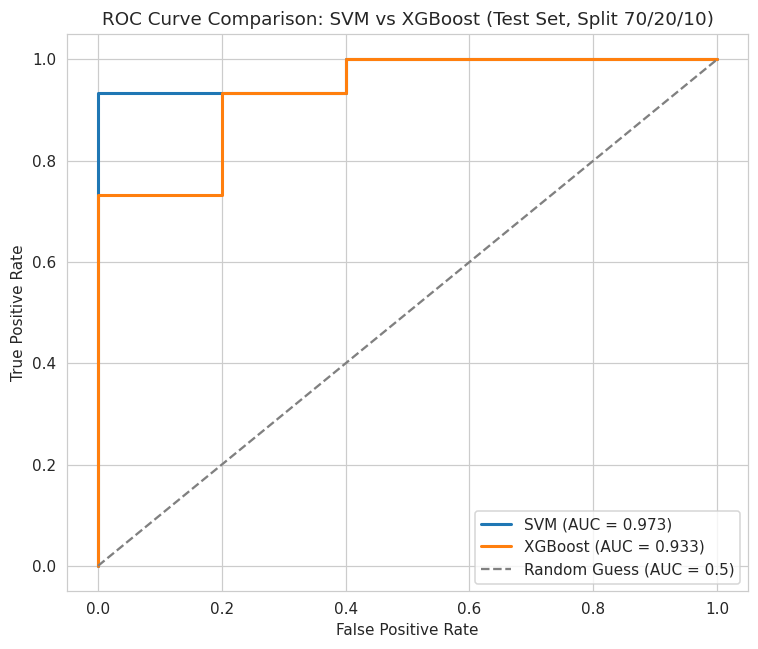

In [43]:
plt.figure(figsize=(7, 6))
for name, res in test_results_7020.items():
    fpr, tpr, _ = roc_curve(y_test_7020, res["y_proba"])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {res["AUC"]:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: SVM vs XGBoost (Test Set, Split 70/20/10)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

,Model,5-Fold CV Accuracy,Hold-Out Test Accuracy
0,SVM,0.9568,0.85
1,XGBoost,0.9351,0.90


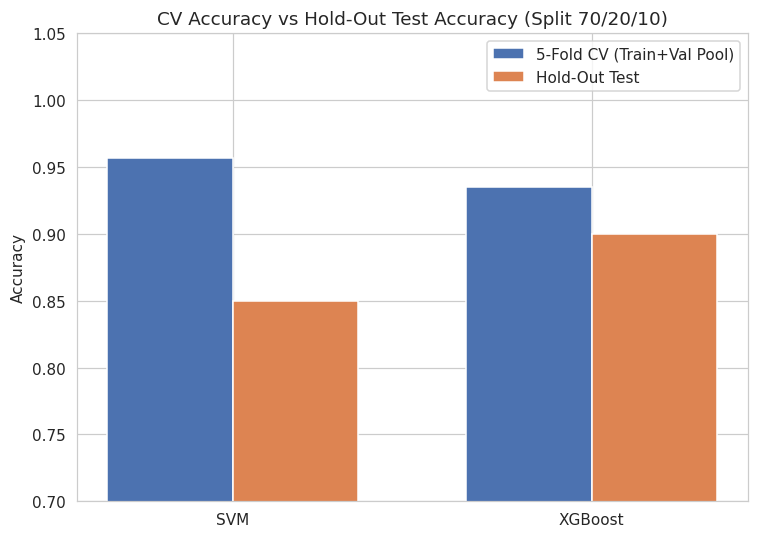

In [44]:
cv_scores_svm_7020 = cross_val_score(best_svm_7020, X_train_final_7020, y_train_smote_7020,
                                       cv=cv_strategy_7020, scoring='accuracy')
cv_scores_xgb_7020 = cross_val_score(best_xgb_7020, X_train_final_7020, y_train_smote_7020,
                                       cv=cv_strategy_7020, scoring='accuracy')

comparison_df_7020 = pd.DataFrame({
    "Model": ["SVM", "XGBoost"],
    "5-Fold CV Accuracy": [cv_scores_svm_7020.mean(), cv_scores_xgb_7020.mean()],
    "Hold-Out Test Accuracy": [test_results_7020["SVM"]["Accuracy"], test_results_7020["XGBoost"]["Accuracy"]]
})
display(comparison_df_7020.round(4))

plt.figure(figsize=(7, 5))
x = np.arange(len(comparison_df_7020))
width = 0.35
plt.bar(x - width/2, comparison_df_7020["5-Fold CV Accuracy"], width, label="5-Fold CV (Train+Val Pool)", color="#4C72B0")
plt.bar(x + width/2, comparison_df_7020["Hold-Out Test Accuracy"], width, label="Hold-Out Test", color="#DD8452")
plt.xticks(x, comparison_df_7020["Model"])
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.05)
plt.title("CV Accuracy vs Hold-Out Test Accuracy (Split 70/20/10)")
plt.legend()
plt.tight_layout()
plt.show()

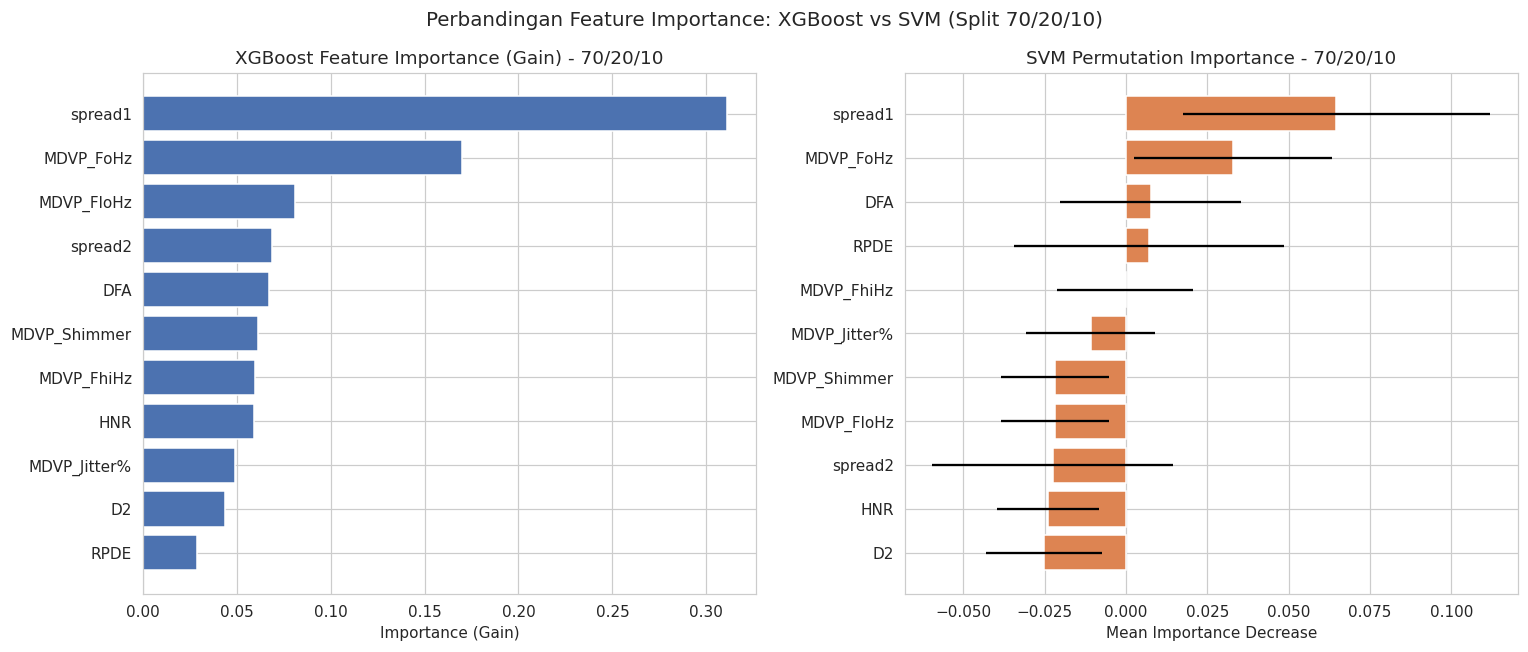

In [45]:
xgb_importance_7020 = pd.Series(best_xgb_7020.feature_importances_, index=selected_features_7020).sort_values(ascending=True)

perm_result_7020 = permutation_importance(best_svm_7020, X_test_final_7020, y_test_7020,
                                            n_repeats=30, random_state=RANDOM_STATE, scoring='f1')
svm_importance_7020 = pd.Series(perm_result_7020.importances_mean, index=selected_features_7020)
svm_importance_std_7020 = pd.Series(perm_result_7020.importances_std, index=selected_features_7020)
svm_importance_sorted_7020 = svm_importance_7020.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(xgb_importance_7020.index, xgb_importance_7020.values, color="#4C72B0")
axes[0].set_title("XGBoost Feature Importance (Gain) - 70/20/10")
axes[0].set_xlabel("Importance (Gain)")

axes[1].barh(svm_importance_sorted_7020.index, svm_importance_sorted_7020.values,
             xerr=svm_importance_std_7020[svm_importance_sorted_7020.index], color="#DD8452")
axes[1].set_title("SVM Permutation Importance - 70/20/10")
axes[1].set_xlabel("Mean Importance Decrease")

plt.suptitle("Perbandingan Feature Importance: XGBoost vs SVM (Split 70/20/10)", fontsize=13)
plt.tight_layout()
plt.show()

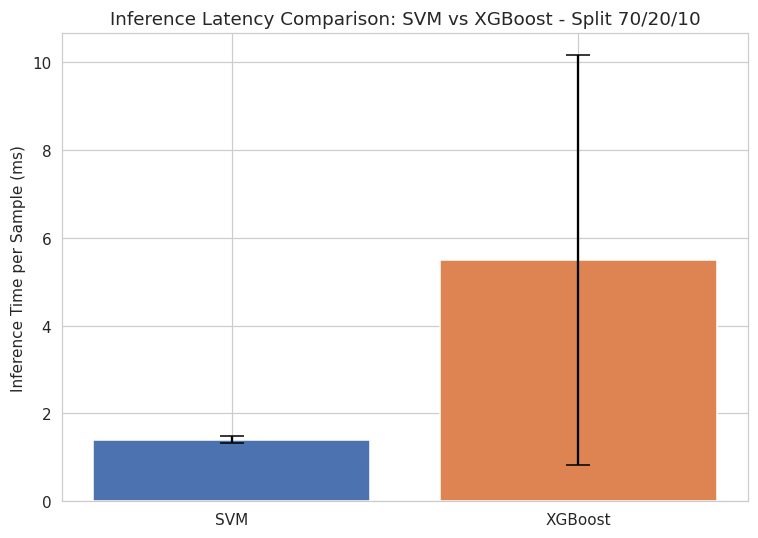

SVM: mean = 1.406 ms | std = 0.085 ms
XGBoost: mean = 5.482 ms | std = 4.663 ms


In [46]:
latency_results_7020 = {}
for name, model in models_7020.items():
    times = []
    for _ in range(n_repeats_latency):
        idx = np.random.randint(0, len(X_test_final_7020))
        sample = X_test_final_7020.iloc[[idx]]
        start = time.perf_counter()
        _ = model.predict(sample)
        end = time.perf_counter()
        times.append((end - start) * 1000)
    latency_results_7020[name] = times

plt.figure(figsize=(7, 5))
plt.bar(latency_results_7020.keys(),
        [np.mean(v) for v in latency_results_7020.values()],
        yerr=[np.std(v) for v in latency_results_7020.values()],
        capsize=8, color=["#4C72B0", "#DD8452"])
plt.ylabel("Inference Time per Sample (ms)")
plt.title("Inference Latency Comparison: SVM vs XGBoost - Split 70/20/10")
plt.tight_layout()
plt.show()

for name, times in latency_results_7020.items():
    print(f"{name}: mean = {np.mean(times):.3f} ms | std = {np.std(times):.3f} ms")

In [47]:
summary_702010 = {
    "split_name": "70/20/10",
    "n_train": len(y_train_7020), "n_val": len(y_val_7020), "n_test": len(y_test_7020),
    "n_features_selected": len(selected_features_7020),
    "selected_features": selected_features_7020,
    "svm_best_params": svm_search_7020.best_params_,
    "xgb_best_params": xgb_search_7020.best_params_,
    "svm_cv_acc": cv_scores_svm_7020.mean(),
    "xgb_cv_acc": cv_scores_xgb_7020.mean(),
    "svm_test": {k: v for k, v in test_results_7020["SVM"].items() if k not in ["y_pred", "y_proba", "cm"]},
    "xgb_test": {k: v for k, v in test_results_7020["XGBoost"].items() if k not in ["y_pred", "y_proba", "cm"]},
    "svm_latency_ms": np.mean(latency_results_7020["SVM"]),
    "xgb_latency_ms": np.mean(latency_results_7020["XGBoost"]),
}

print("RINGKASAN PIPELINE SPLIT 70/20/10 \n")
print(f"Train: {summary_702010['n_train']} | Val: {summary_702010['n_val']} | Test: {summary_702010['n_test']}")
print(f"Fitur terpilih: {summary_702010['n_features_selected']} dari 22 fitur awal\n")
display(pd.DataFrame({"SVM": summary_702010["svm_test"], "XGBoost": summary_702010["xgb_test"]}).round(4))
print(f"\nGap CV vs Test - SVM     : {summary_702010['svm_cv_acc'] - summary_702010['svm_test']['Accuracy']:.4f}")
print(f"Gap CV vs Test - XGBoost : {summary_702010['xgb_cv_acc'] - summary_702010['xgb_test']['Accuracy']:.4f}")

RINGKASAN PIPELINE SPLIT 70/20/10 

Train: 136 | Val: 39 | Test: 20
Fitur terpilih: 11 dari 22 fitur awal



,SVM,XGBoost
Accuracy,0.8500,0.9000
Precision,0.8750,0.9333
Recall,0.9333,0.9333
F1,0.9032,0.9333
Specificity,0.6000,0.8000
AUC,0.9733,0.9333



Gap CV vs Test - SVM     : 0.1068
Gap CV vs Test - XGBoost : 0.0351


Rangkuman

In [48]:
all_summaries = [summary_602020, summary_801010, summary_702010]

# Tabel 1: Ukuran Partisi & Jumlah Fitur
partition_rows = []
for s in all_summaries:
    partition_rows.append({
        "Split Scheme": s["split_name"],
        "N Train": s["n_train"],
        "N Val": s["n_val"],
        "N Test": s["n_test"],
        "N Features Selected": s["n_features_selected"]
    })
partition_df = pd.DataFrame(partition_rows)
print("Tabel 1: Ukuran Partisi Data & Fitur Terpilih")
display(partition_df)

# Tabel 2: Performa Test Set - SVM
svm_rows = []
for s in all_summaries:
    row = {"Split Scheme": s["split_name"]}
    row.update(s["svm_test"])
    svm_rows.append(row)
svm_comparison_df = pd.DataFrame(svm_rows).set_index("Split Scheme")
print("\nTabel 2: Performa Test Set - SVM, lintas Skema Split")
display(svm_comparison_df.round(4))

#Tabel 3: Performa Test Set - XGBoost
xgb_rows = []
for s in all_summaries:
    row = {"Split Scheme": s["split_name"]}
    row.update(s["xgb_test"])
    xgb_rows.append(row)
xgb_comparison_df = pd.DataFrame(xgb_rows).set_index("Split Scheme")
print("\nTabel 3: Performa Test Set - XGBoost, lintas Skema Split")
display(xgb_comparison_df.round(4))

# Tabel 4: CV Accuracy vs Hold-Out Accuracy (Gap)
gap_rows = []
for s in all_summaries:
    gap_rows.append({
        "Split Scheme": s["split_name"],
        "SVM CV Acc": s["svm_cv_acc"],
        "SVM Test Acc": s["svm_test"]["Accuracy"],
        "SVM Gap": s["svm_cv_acc"] - s["svm_test"]["Accuracy"],
        "XGB CV Acc": s["xgb_cv_acc"],
        "XGB Test Acc": s["xgb_test"]["Accuracy"],
        "XGB Gap": s["xgb_cv_acc"] - s["xgb_test"]["Accuracy"]
    })
gap_df = pd.DataFrame(gap_rows)
print("\nTabel 4: Gap antara CV Accuracy dan Hold-Out Test Accuracy")
display(gap_df.round(4))

# Tabel 5: Inference Latency
latency_rows = []
for s in all_summaries:
    latency_rows.append({
        "Split Scheme": s["split_name"],
        "SVM Latency (ms)": s["svm_latency_ms"],
        "XGBoost Latency (ms)": s["xgb_latency_ms"]
    })
latency_df = pd.DataFrame(latency_rows)
print("\nTabel 5: Inference Latency lintas Skema Split")
display(latency_df.round(4))

Tabel 1: Ukuran Partisi Data & Fitur Terpilih


,Split Scheme,N Train,N Val,N Test,N Features Selected
0,60/20/20,117,39,39,11
1,80/10/10,156,19,20,11
2,70/20/10,136,39,20,11



Tabel 2: Performa Test Set - SVM, lintas Skema Split


,Accuracy,Precision,Recall,F1,Specificity,AUC
Split Scheme,,,,,,
60/20/20,0.9231,0.9333,0.9655,0.9492,0.8,0.9138
80/10/10,1.0000,1.0000,1.0000,1.0000,1.0,1.0000
70/20/10,0.8500,0.8750,0.9333,0.9032,0.6,0.9733



Tabel 3: Performa Test Set - XGBoost, lintas Skema Split


,Accuracy,Precision,Recall,F1,Specificity,AUC
Split Scheme,,,,,,
60/20/20,0.8718,0.9000,0.9310,0.9153,0.7,0.9000
80/10/10,0.9500,1.0000,0.9333,0.9655,1.0,1.0000
70/20/10,0.9000,0.9333,0.9333,0.9333,0.8,0.9333



Tabel 4: Gap antara CV Accuracy dan Hold-Out Test Accuracy


,Split Scheme,SVM CV Acc,SVM Test Acc,SVM Gap,XGB CV Acc,XGB Test Acc,XGB Gap
0,60/20/20,0.9236,0.9231,0.0005,0.9240,0.8718,0.0522
1,80/10/10,0.9671,1.0000,-0.0329,0.9435,0.9500,-0.0065
2,70/20/10,0.9568,0.8500,0.1068,0.9351,0.9000,0.0351



Tabel 5: Inference Latency lintas Skema Split


,Split Scheme,SVM Latency (ms),XGBoost Latency (ms)
0,60/20/20,1.0073,1.6566
1,80/10/10,0.9653,1.6677
2,70/20/10,1.4055,5.4820


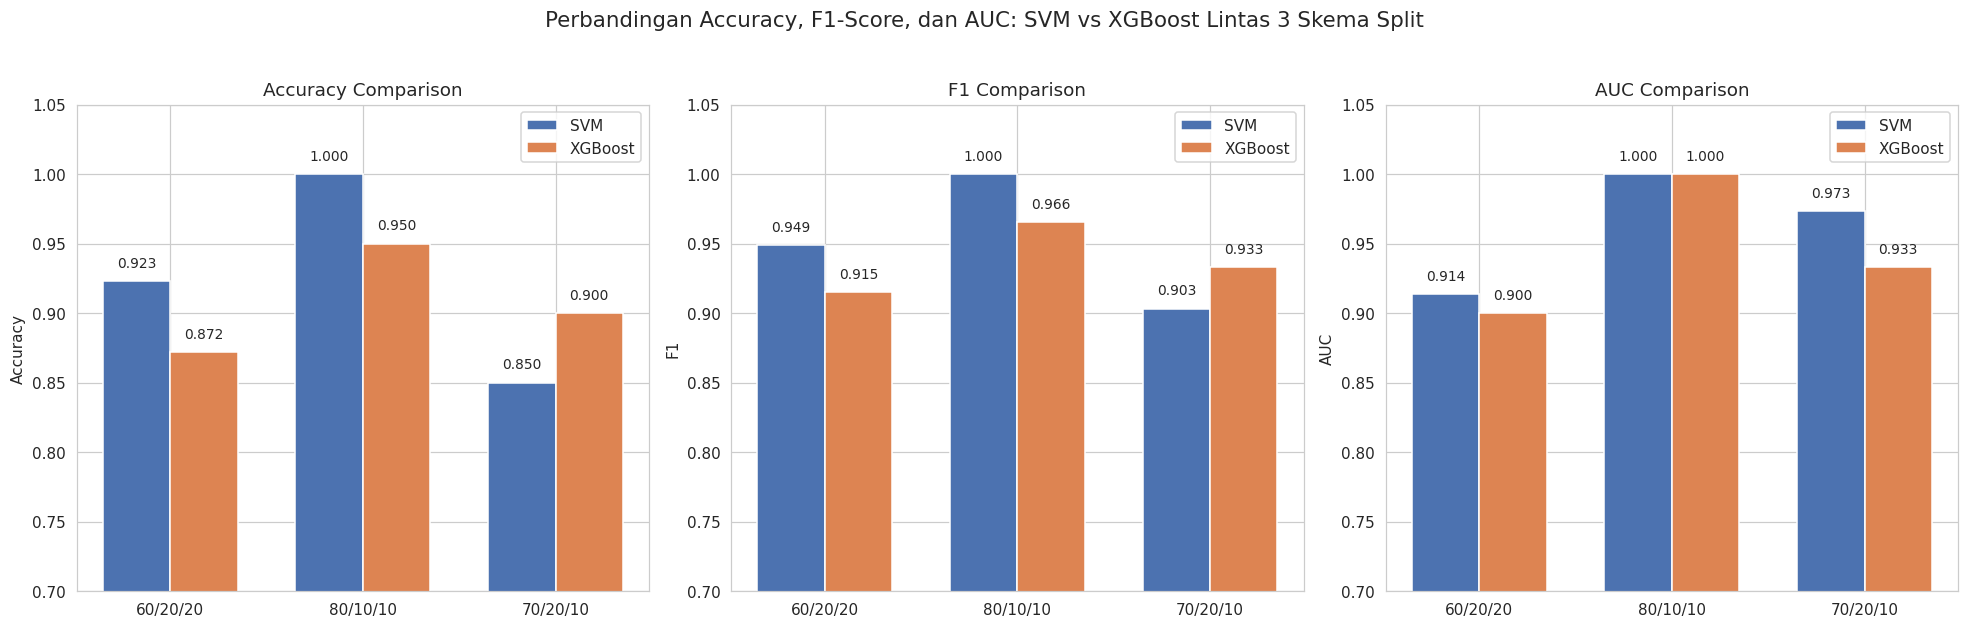

In [49]:
metrics_to_plot = ["Accuracy", "F1", "AUC"]
split_order = ["60/20/20", "80/10/10", "70/20/10"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i, metric in enumerate(metrics_to_plot):
    svm_vals = [svm_comparison_df.loc[s, metric] for s in split_order]
    xgb_vals = [xgb_comparison_df.loc[s, metric] for s in split_order]

    x = np.arange(len(split_order))
    width = 0.35

    axes[i].bar(x - width/2, svm_vals, width, label="SVM", color="#4C72B0")
    axes[i].bar(x + width/2, xgb_vals, width, label="XGBoost", color="#DD8452")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(split_order)
    axes[i].set_title(f"{metric} Comparison")
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0.7, 1.05)
    axes[i].legend()

    # Tambahkan label nilai di atas bar
    for j, (sv, xv) in enumerate(zip(svm_vals, xgb_vals)):
        axes[i].text(j - width/2, sv + 0.01, f"{sv:.3f}", ha='center', fontsize=9)
        axes[i].text(j + width/2, xv + 0.01, f"{xv:.3f}", ha='center', fontsize=9)

plt.suptitle("Perbandingan Accuracy, F1-Score, dan AUC: SVM vs XGBoost Lintas 3 Skema Split",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

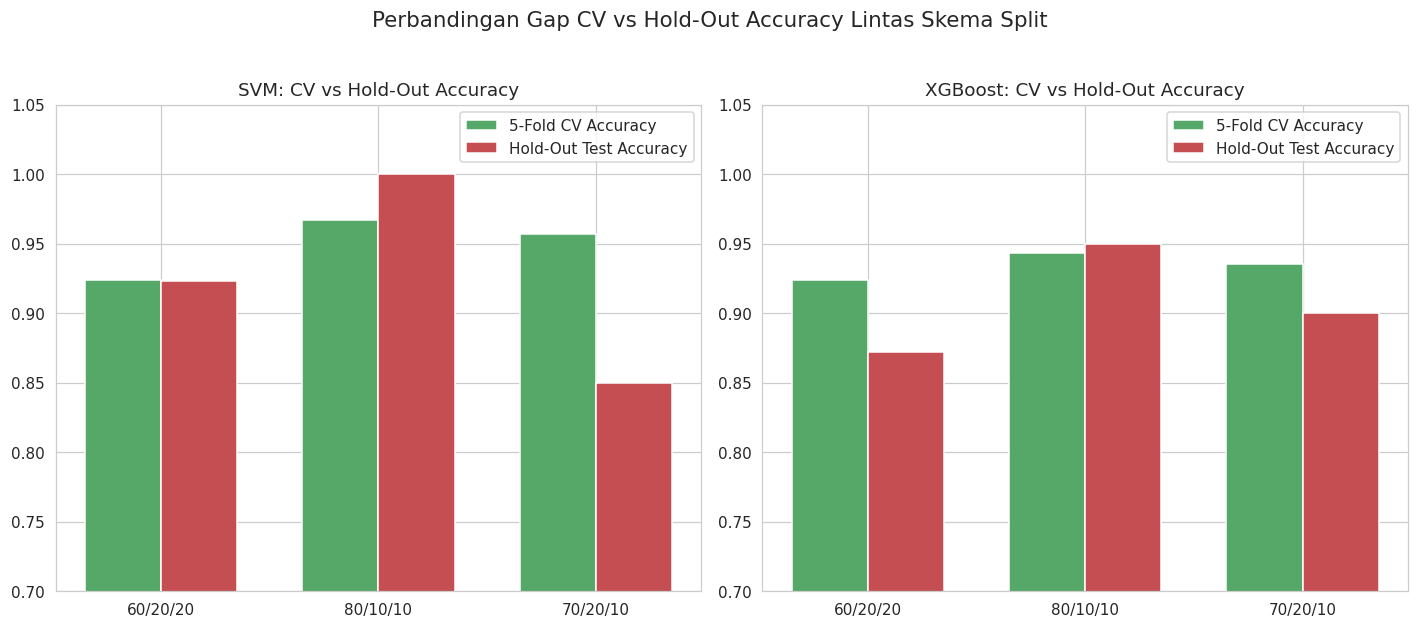

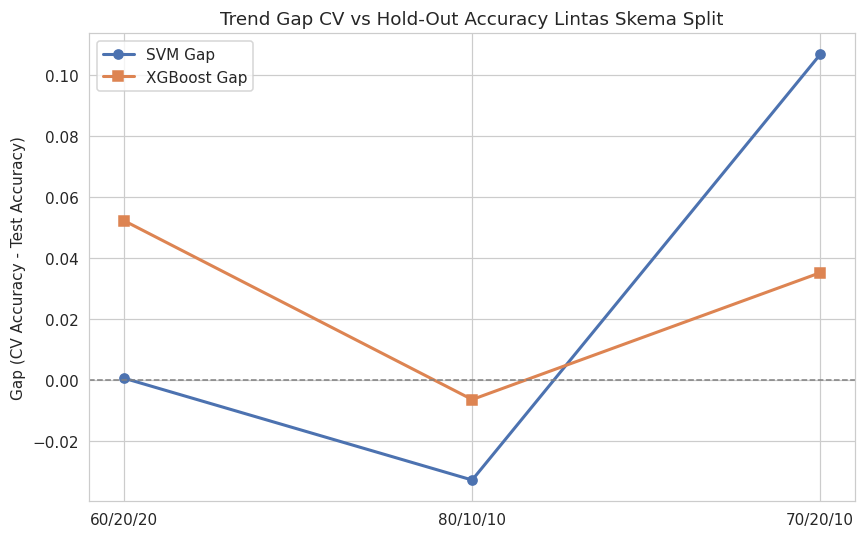

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

x = np.arange(len(split_order))
width = 0.35

# Panel kiri: SVM
svm_cv = [gap_df[gap_df["Split Scheme"] == s]["SVM CV Acc"].values[0] for s in split_order]
svm_test = [gap_df[gap_df["Split Scheme"] == s]["SVM Test Acc"].values[0] for s in split_order]

axes[0].bar(x - width/2, svm_cv, width, label="5-Fold CV Accuracy", color="#55A868")
axes[0].bar(x + width/2, svm_test, width, label="Hold-Out Test Accuracy", color="#C44E52")
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_order)
axes[0].set_title("SVM: CV vs Hold-Out Accuracy")
axes[0].set_ylim(0.7, 1.05)
axes[0].legend()

# Panel kanan: XGBoost
xgb_cv = [gap_df[gap_df["Split Scheme"] == s]["XGB CV Acc"].values[0] for s in split_order]
xgb_test = [gap_df[gap_df["Split Scheme"] == s]["XGB Test Acc"].values[0] for s in split_order]

axes[1].bar(x - width/2, xgb_cv, width, label="5-Fold CV Accuracy", color="#55A868")
axes[1].bar(x + width/2, xgb_test, width, label="Hold-Out Test Accuracy", color="#C44E52")
axes[1].set_xticks(x)
axes[1].set_xticklabels(split_order)
axes[1].set_title("XGBoost: CV vs Hold-Out Accuracy")
axes[1].set_ylim(0.7, 1.05)
axes[1].legend()

plt.suptitle("Perbandingan Gap CV vs Hold-Out Accuracy Lintas Skema Split", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

# Line chart
plt.figure(figsize=(8, 5))
plt.plot(split_order, gap_df["SVM Gap"], marker='o', linewidth=2, label="SVM Gap", color="#4C72B0")
plt.plot(split_order, gap_df["XGB Gap"], marker='s', linewidth=2, label="XGBoost Gap", color="#DD8452")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel("Gap (CV Accuracy - Test Accuracy)")
plt.title("Trend Gap CV vs Hold-Out Accuracy Lintas Skema Split")
plt.legend()
plt.tight_layout()
plt.show()

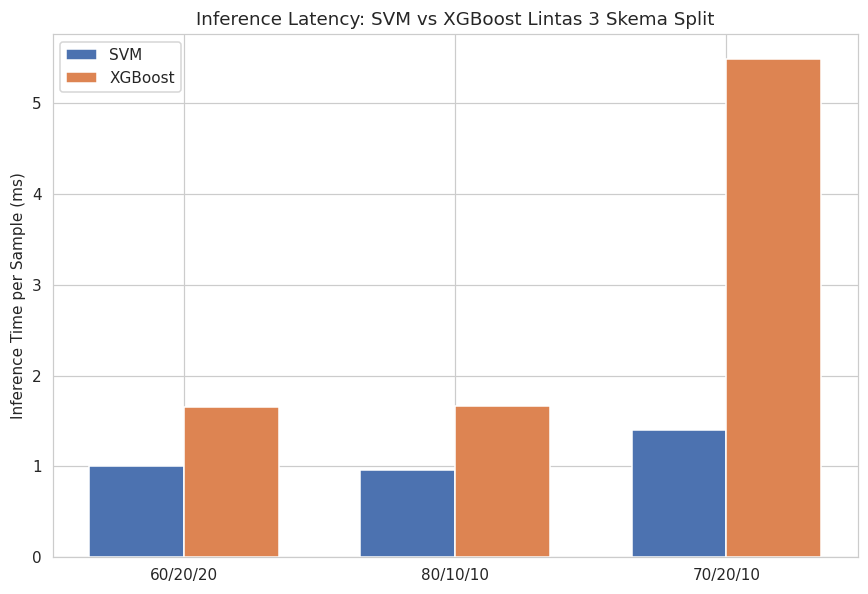

In [51]:
fig, ax = plt.subplots(figsize=(8, 5.5))

x = np.arange(len(split_order))
width = 0.35

svm_lat = [latency_df[latency_df["Split Scheme"] == s]["SVM Latency (ms)"].values[0] for s in split_order]
xgb_lat = [latency_df[latency_df["Split Scheme"] == s]["XGBoost Latency (ms)"].values[0] for s in split_order]

ax.bar(x - width/2, svm_lat, width, label="SVM", color="#4C72B0")
ax.bar(x + width/2, xgb_lat, width, label="XGBoost", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(split_order)
ax.set_ylabel("Inference Time per Sample (ms)")
ax.set_title("Inference Latency: SVM vs XGBoost Lintas 3 Skema Split")
ax.legend()

plt.tight_layout()
plt.show()

In [52]:
final_table_rows = []
for s in all_summaries:
    final_table_rows.append({
        "Split": s["split_name"],
        "N Test": s["n_test"],
        "SVM Acc": s["svm_test"]["Accuracy"],
        "SVM F1": s["svm_test"]["F1"],
        "SVM AUC": s["svm_test"]["AUC"],
        "SVM Gap (CV-Test)": s["svm_cv_acc"] - s["svm_test"]["Accuracy"],
        "XGB Acc": s["xgb_test"]["Accuracy"],
        "XGB F1": s["xgb_test"]["F1"],
        "XGB AUC": s["xgb_test"]["AUC"],
        "XGB Gap (CV-Test)": s["xgb_cv_acc"] - s["xgb_test"]["Accuracy"],
    })

final_table = pd.DataFrame(final_table_rows).set_index("Split")
print("TABEL KONSOLIDASI AKHIR: PERBANDINGAN 3 SKEMA SPLIT\n")
display(final_table.round(4))

print("\nHighlight Nilai Terbaik per Metrik")
display(final_table.style.highlight_max(
    subset=["SVM Acc", "SVM F1", "SVM AUC", "XGB Acc", "XGB F1", "XGB AUC"],
    color="lightgreen"
).highlight_min(
    subset=["SVM Gap (CV-Test)", "XGB Gap (CV-Test)"],
    color="lightblue"
))

TABEL KONSOLIDASI AKHIR: PERBANDINGAN 3 SKEMA SPLIT



,N Test,SVM Acc,SVM F1,SVM AUC,SVM Gap (CV-Test),XGB Acc,XGB F1,XGB AUC,XGB Gap (CV-Test)
Split,,,,,,,,,
60/20/20,39,0.9231,0.9492,0.9138,0.0005,0.8718,0.9153,0.9000,0.0522
80/10/10,20,1.0000,1.0000,1.0000,-0.0329,0.9500,0.9655,1.0000,-0.0065
70/20/10,20,0.8500,0.9032,0.9733,0.1068,0.9000,0.9333,0.9333,0.0351



Highlight Nilai Terbaik per Metrik


,N Test,SVM Acc,SVM F1,SVM AUC,SVM Gap (CV-Test),XGB Acc,XGB F1,XGB AUC,XGB Gap (CV-Test)
Split,,,,,,,,,
60/20/20,39,0.923077,0.949153,0.913793,0.000512,0.871795,0.915254,0.900000,0.052197
80/10/10,20,1.000000,1.000000,1.000000,-0.032890,0.950000,0.965517,1.000000,-0.006478
70/20/10,20,0.850000,0.903226,0.973333,0.106757,0.900000,0.933333,0.933333,0.035135


In [53]:
print("RINGKASAN INTERPRETASI AKHIR")

best_svm_acc_split = final_table["SVM Acc"].idxmax()
best_xgb_acc_split = final_table["XGB Acc"].idxmax()
most_stable_svm_split = final_table["SVM Gap (CV-Test)"].abs().idxmin()
most_stable_xgb_split = final_table["XGB Gap (CV-Test)"].abs().idxmin()

print(f"""
1. SKEMA DENGAN AKURASI TEST TERTINGGI
   - SVM mencatatkan akurasi test tertinggi pada skema {best_svm_acc_split}
     ({final_table.loc[best_svm_acc_split, 'SVM Acc']:.4f})
   - XGBoost mencatatkan akurasi test tertinggi pada skema {best_xgb_acc_split}
     ({final_table.loc[best_xgb_acc_split, 'XGB Acc']:.4f})

2. SKEMA DENGAN GAP CV-TEST PALING KECIL (PALING STABIL)
   - SVM paling stabil pada skema {most_stable_svm_split}
     (gap = {final_table.loc[most_stable_svm_split, 'SVM Gap (CV-Test)']:.4f})
   - XGBoost paling stabil pada skema {most_stable_xgb_split}
     (gap = {final_table.loc[most_stable_xgb_split, 'XGB Gap (CV-Test)']:.4f})

3. KONSISTENSI FEATURE SELECTION LINTAS SKEMA
   - Fitur terpilih pada 60/20/20: {len(summary_602020['selected_features'])} fitur
   - Fitur terpilih pada 80/10/10: {len(summary_801010['selected_features'])} fitur
   - Fitur terpilih pada 70/20/10: {len(summary_702010['selected_features'])} fitur
""")

RINGKASAN INTERPRETASI AKHIR

1. SKEMA DENGAN AKURASI TEST TERTINGGI
   - SVM mencatatkan akurasi test tertinggi pada skema 80/10/10
     (1.0000)
   - XGBoost mencatatkan akurasi test tertinggi pada skema 80/10/10
     (0.9500)

2. SKEMA DENGAN GAP CV-TEST PALING KECIL (PALING STABIL)
   - SVM paling stabil pada skema 60/20/20
     (gap = 0.0005)
   - XGBoost paling stabil pada skema 80/10/10
     (gap = -0.0065)

3. KONSISTENSI FEATURE SELECTION LINTAS SKEMA
   - Fitur terpilih pada 60/20/20: 11 fitur
   - Fitur terpilih pada 80/10/10: 11 fitur
   - Fitur terpilih pada 70/20/10: 11 fitur

